# LipidBlast Dataset EDA

Exploratory analysis of the LipidBlast 2022 MS2 spectral library (~552K spectra, 77 lipid classes). Key findings: spectra are extremely sparse (~5 peaks), intensities are categorical (only ~7 discrete tiers), and ~423 unique intensity templates cover the entire library.

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data.loader import load_library

FIGURES_DIR = os.path.join(os.path.dirname(os.getcwd()), "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=0.95)
plt.rcParams.update({
    "figure.figsize": (6, 2),
    "figure.dpi": 150,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "svg.fonttype": "none",
})

%matplotlib inline

## 1. Load Data & Basic Stats

In [2]:
df = load_library()

# Derived columns used by the script
df["max_intensity"] = df["intensity_list"].apply(lambda x: x.max() if len(x) > 0 else 0)
df["total_intensity"] = df["intensity_list"].apply(lambda x: x.sum() if len(x) > 0 else 0)

print(f"Spectra:          {len(df):,}")
print(f"Columns:          {list(df.columns)}")
print(f"Unique names:     {df['name'].nunique():,}")
print(f"Unique InChIKeys: {df['inchikey'].nunique():,}")
print(f"Lipid classes:    {df['lipid_class'].nunique()}")
print(f"Ion modes:        {df['mode'].value_counts().to_dict()}")
print(f"Precursor m/z:    {df['precursor_mz'].min():.2f} - {df['precursor_mz'].max():.2f} (median {df['precursor_mz'].median():.2f})")
print(f"Peaks/spectrum:   {df['n_peaks'].min()} - {df['n_peaks'].max()} (median {df['n_peaks'].median():.0f}, mean {df['n_peaks'].mean():.1f})")

if "isomeric_smiles" in df.columns:
    n_smiles = df["isomeric_smiles"].notna().sum()
    print(f"SMILES available: {n_smiles:,} / {len(df):,} ({n_smiles/len(df):.1%})")

df.head(3)

Removed 384 spectra with <2 peaks


Spectra:          551,890
Columns:          ['name', 'isomeric_smiles', 'adduct_name', 'precursor_mz', 'mode', 'mz_list', 'intensity_list', 'formula', 'exact_mass', 'inchikey', 'db_id', 'lipid_class', 'n_peaks', 'max_intensity', 'total_intensity']
Unique names:     551,890
Unique InChIKeys: 540,956
Lipid classes:    77
Ion modes:        {'positive': 279971, 'negative': 271919}
Precursor m/z:    152.09 - 2014.58 (median 997.82)
Peaks/spectrum:   2 - 14 (median 5, mean 5.8)


SMILES available: 551,890 / 551,890 (100.0%)


,name,isomeric_smiles,adduct_name,precursor_mz,mode,mz_list,intensity_list,formula,exact_mass,inchikey,db_id,lipid_class,n_peaks,max_intensity,total_intensity
0,HexCer 27:3;3O/15:0;(2OH),CCCCCCCCCCCCCC(O)C(=O)NC(COC1OC(CO)C(O)C(O)C1O...,[M+CH3COO]-,898.66251,negative,"[179.0556, 211.2067, 257.2122, 282.2428, 312.2...","[20.02001953125, 10.010009765625, 20.020019531...",C48H89NO10,839.648648,UPRBUKAYMJDHAS-GFCORCDENA-N,LipidBlast2022_999999,HexCer,8,100.0,241.141138
1,HexCer 27:3;3O/14:1;(2OH),CCCCCCCCCC\C=C\CC\C=C\CC\C=C\CCCC(O)C(O)C(COC1...,[M+CH3COO]-,882.63121,negative,"[179.0556, 195.1754, 241.1809, 266.2115, 296.2...","[20.02001953125, 10.010009765625, 20.020019531...",C47H85NO10,823.617348,XEAUYRLBGHPAMY-VAUSSYLONA-N,LipidBlast2022_999998,HexCer,8,100.0,241.141138
2,HexCer 27:3;3O/14:0;(2OH),CCCCCCCCCCCCC(O)C(=O)NC(COC1OC(CO)C(O)C(O)C1O)...,[M+CH3COO]-,884.64686,negative,"[179.0556, 197.1911, 243.1966, 268.2271, 298.2...","[20.02001953125, 10.010009765625, 20.020019531...",C47H87NO10,825.632998,RLSYOCVOMLVRBP-SXXXEOEDNA-N,LipidBlast2022_999997,HexCer,8,100.0,241.141138


## 2. Summary Statistics Panel

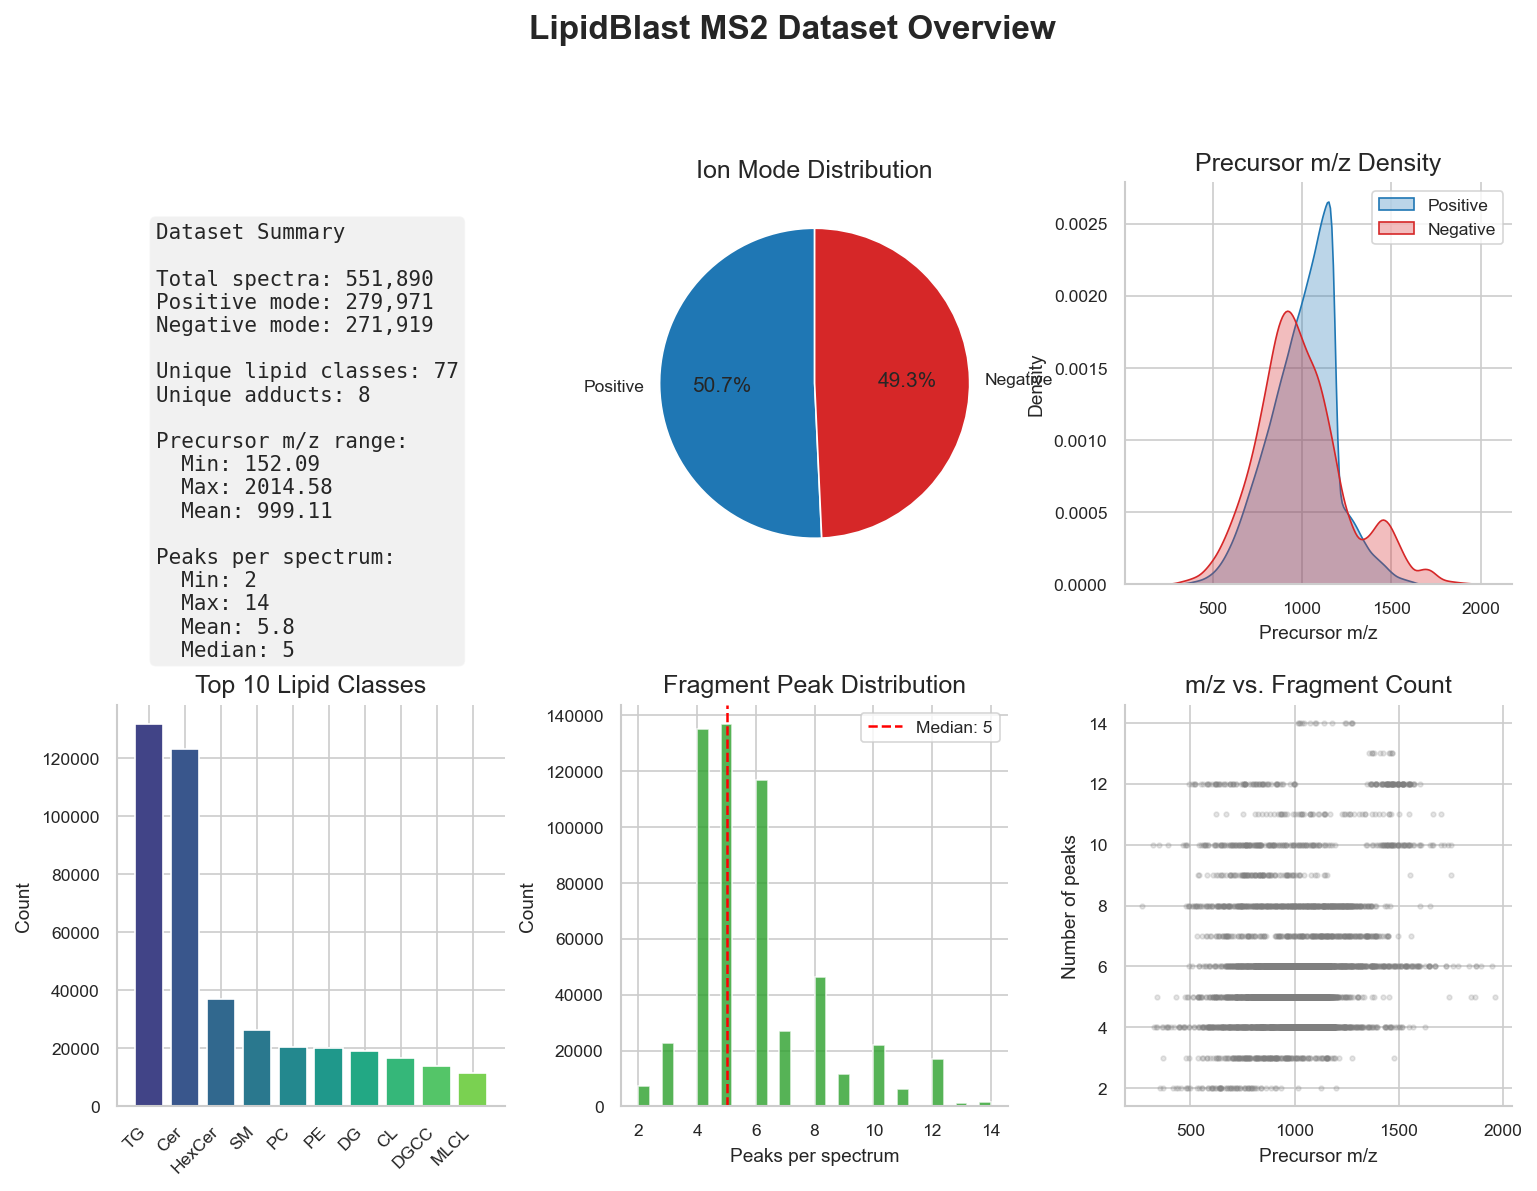

In [3]:
from matplotlib.ticker import MaxNLocator

fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 1. Dataset overview (text)
ax = fig.add_subplot(gs[0, 0])
ax.axis("off")
stats_text = f"""Dataset Summary

Total spectra: {len(df):,}
Positive mode: {len(df[df['mode'] == 'positive']):,}
Negative mode: {len(df[df['mode'] == 'negative']):,}

Unique lipid classes: {df['lipid_class'].nunique():,}
Unique adducts: {df['adduct_name'].nunique():,}

Precursor m/z range:
  Min: {df['precursor_mz'].min():.2f}
  Max: {df['precursor_mz'].max():.2f}
  Mean: {df['precursor_mz'].mean():.2f}

Peaks per spectrum:
  Min: {df['n_peaks'].min()}
  Max: {df['n_peaks'].max()}
  Mean: {df['n_peaks'].mean():.1f}
  Median: {df['n_peaks'].median():.0f}"""
ax.text(0.1, 0.9, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment="top", fontfamily="monospace",
        bbox=dict(boxstyle="round", facecolor="lightgray", alpha=0.3))

# 2. Pie chart of ion modes
ax = fig.add_subplot(gs[0, 1])
mode_counts = df["mode"].value_counts()
ax.pie(mode_counts.values, labels=mode_counts.index.str.capitalize(),
       autopct="%1.1f%%", colors=["#1f77b4", "#d62728"], startangle=90)
ax.set_title("Ion Mode Distribution")

# 3. Precursor m/z density by mode
ax = fig.add_subplot(gs[0, 2])
for mode, color in [("positive", "#1f77b4"), ("negative", "#d62728")]:
    subset = df[df["mode"] == mode]
    sns.kdeplot(data=subset["precursor_mz"], ax=ax, color=color,
                label=mode.capitalize(), fill=True, alpha=0.3)
ax.set_xlabel("Precursor m/z")
ax.set_ylabel("Density")
ax.set_title("Precursor m/z Density")
ax.legend()

# 4. Top 10 lipid classes
ax = fig.add_subplot(gs[1, 0])
top_classes = df["lipid_class"].value_counts().head(10)
ax.bar(range(len(top_classes)), top_classes.values,
       color=plt.cm.viridis(np.linspace(0.2, 0.8, len(top_classes))))
ax.set_xticks(range(len(top_classes)))
ax.set_xticklabels(top_classes.index, rotation=45, ha="right")
ax.set_ylabel("Count")
ax.set_title("Top 10 Lipid Classes")

# 5. Peaks per spectrum distribution
ax = fig.add_subplot(gs[1, 1])
ax.hist(df["n_peaks"], bins=30, alpha=0.8, color="#2ca02c", edgecolor="white")
ax.axvline(df["n_peaks"].median(), color="red", linestyle="--",
           label=f"Median: {df['n_peaks'].median():.0f}")
ax.set_xlabel("Peaks per spectrum")
ax.set_ylabel("Count")
ax.set_title("Fragment Peak Distribution")
ax.legend()

# 6. Precursor m/z vs peaks scatter (sampled)
ax = fig.add_subplot(gs[1, 2])
sample_overview = df.sample(min(5000, len(df)), random_state=42)
ax.scatter(sample_overview["precursor_mz"], sample_overview["n_peaks"],
           alpha=0.2, s=5, c="#7f7f7f")
ax.set_xlabel("Precursor m/z")
ax.set_ylabel("Number of peaks")
ax.set_title("m/z vs. Fragment Count")

plt.suptitle("LipidBlast MS2 Dataset Overview", fontsize=16, fontweight="bold", y=1.02)
plt.savefig(os.path.join(FIGURES_DIR, "summary_statistics.png"), bbox_inches="tight")
plt.show()

## 3. Spectrum Characteristics

/tmp/ipykernel_2481294/2882455580.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(class_data, vert=False, labels=top10, patch_artist=True,


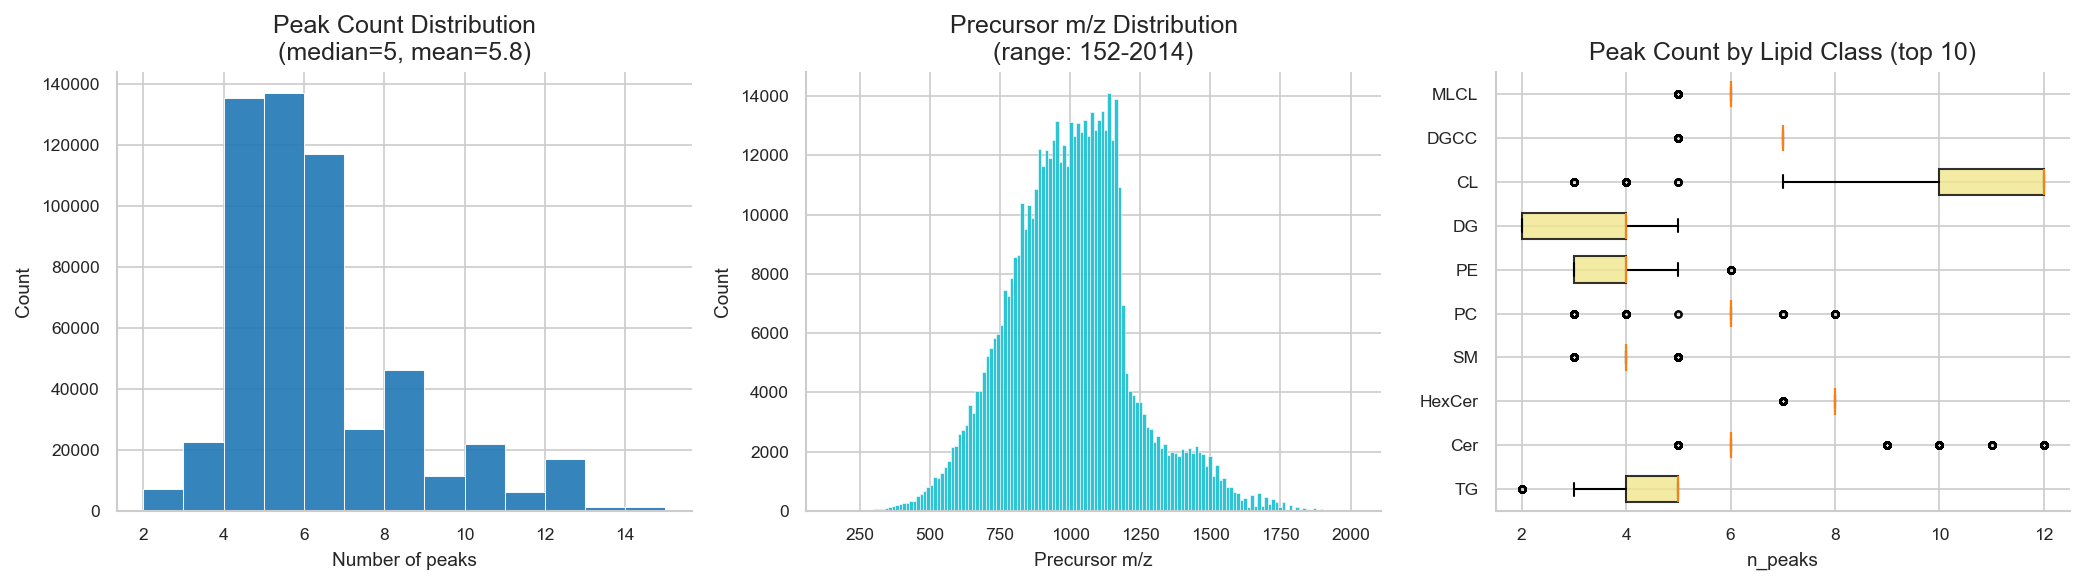

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Peak count distribution
ax = axes[0]
ax.hist(df["n_peaks"], bins=range(2, df["n_peaks"].max() + 2), alpha=0.9,
        color="#1f77b4", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Number of peaks")
ax.set_ylabel("Count")
med, mean = df["n_peaks"].median(), df["n_peaks"].mean()
ax.set_title(f"Peak Count Distribution\n(median={med:.0f}, mean={mean:.1f})")

# Precursor m/z distribution
ax = axes[1]
ax.hist(df["precursor_mz"], bins=150, alpha=0.9, color="#17becf",
        edgecolor="white", linewidth=0.3)
ax.set_xlabel("Precursor m/z")
ax.set_ylabel("Count")
lo, hi = int(df["precursor_mz"].min()), int(df["precursor_mz"].max())
ax.set_title(f"Precursor m/z Distribution\n(range: {lo}-{hi})")

# Peak count by lipid class (horizontal boxplot)
ax = axes[2]
top10 = df["lipid_class"].value_counts().head(10).index.tolist()
class_data = [df.loc[df["lipid_class"] == c, "n_peaks"] for c in top10]
bp = ax.boxplot(class_data, vert=False, labels=top10, patch_artist=True,
                widths=0.6, flierprops=dict(marker="o", markersize=3, alpha=0.5))
for patch in bp["boxes"]:
    patch.set_facecolor("#f0e68c")
    patch.set_alpha(0.8)
ax.set_xlabel("n_peaks")
ax.set_title("Peak Count by Lipid Class (top 10)")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "spectrum_characteristics.png"), bbox_inches="tight")
plt.show()

## 4. Precursor m/z by Ion Mode

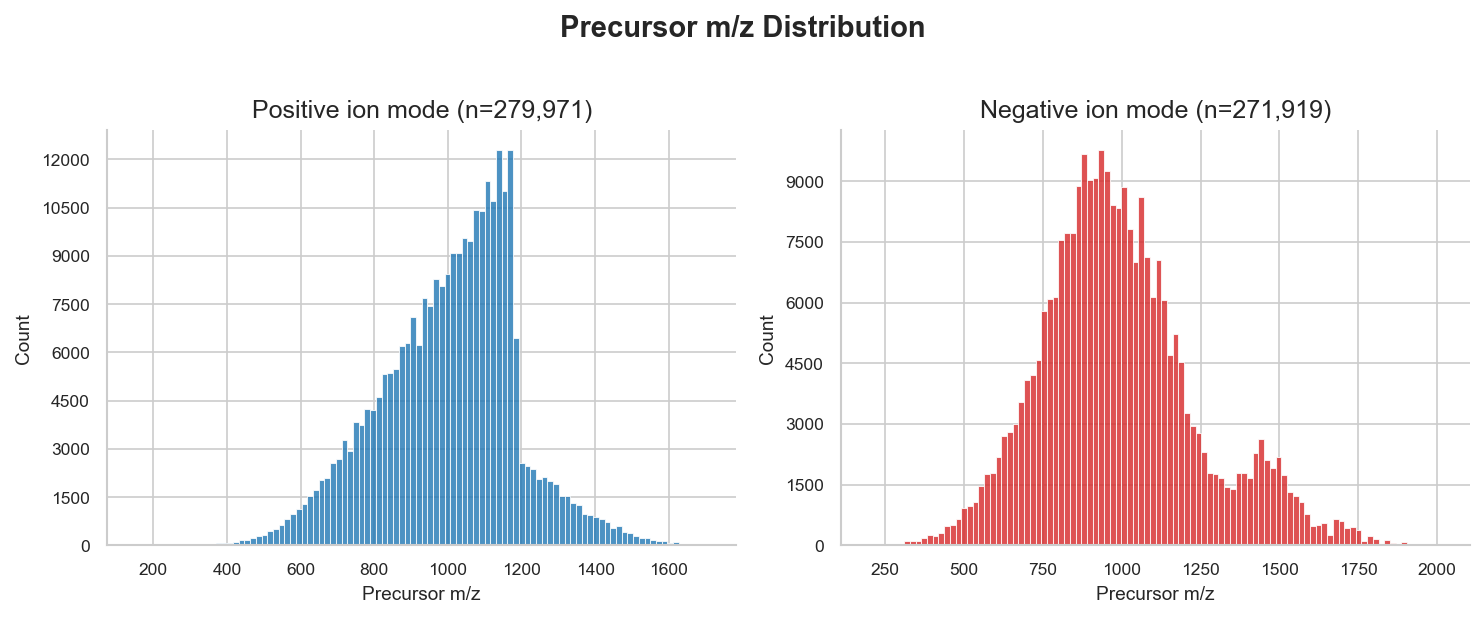

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, mode in zip(axes, ["positive", "negative"]):
    subset = df[df["mode"] == mode]
    ax.hist(subset["precursor_mz"], bins=100, alpha=0.8,
            color="#1f77b4" if mode == "positive" else "#d62728",
            edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Precursor m/z")
    ax.set_ylabel("Count")
    ax.set_title(f"{mode.capitalize()} ion mode (n={len(subset):,})")
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.suptitle("Precursor m/z Distribution", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "precursor_mz_distribution.png"), bbox_inches="tight")
plt.show()

## 5. Lipid Class Distribution

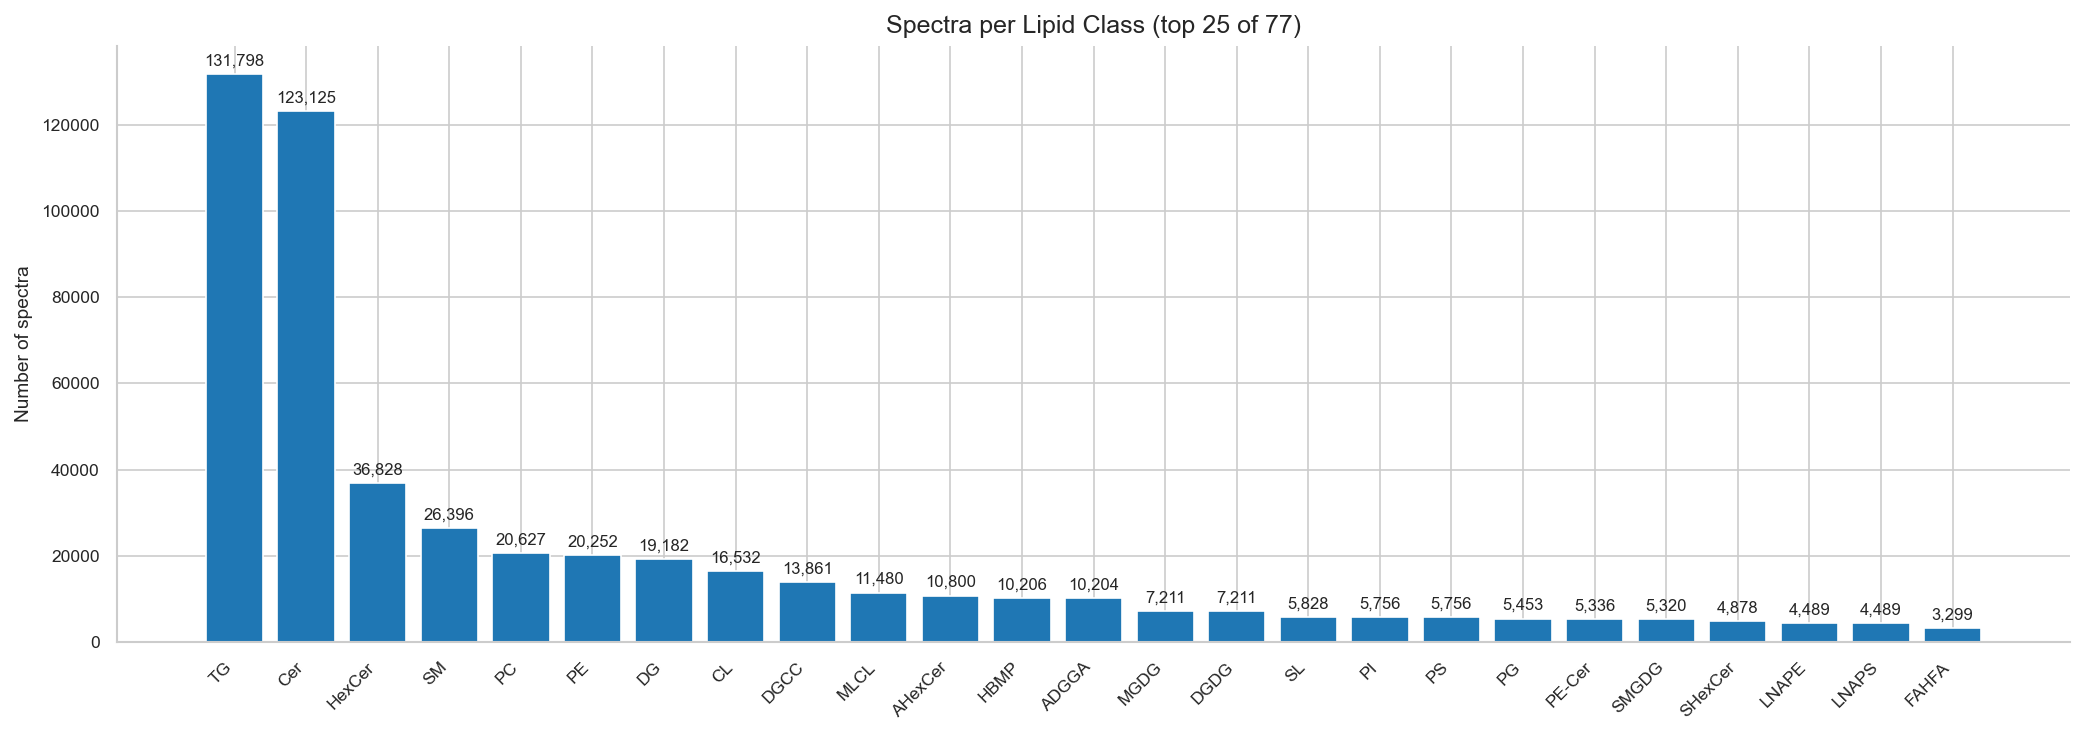

In [6]:
class_counts = df["lipid_class"].value_counts().head(25)
n_classes = df["lipid_class"].nunique()

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(len(class_counts)), class_counts.values, color="#1f77b4", edgecolor="white")

for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(class_counts) * 0.01,
            f"{count:,}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(range(len(class_counts)))
ax.set_xticklabels(class_counts.index, rotation=45, ha="right")
ax.set_ylabel("Number of spectra")
ax.set_title(f"Spectra per Lipid Class (top {len(class_counts)} of {n_classes})")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "class_distribution.png"), bbox_inches="tight")
plt.show()

## 6. Adduct & Mode Distribution

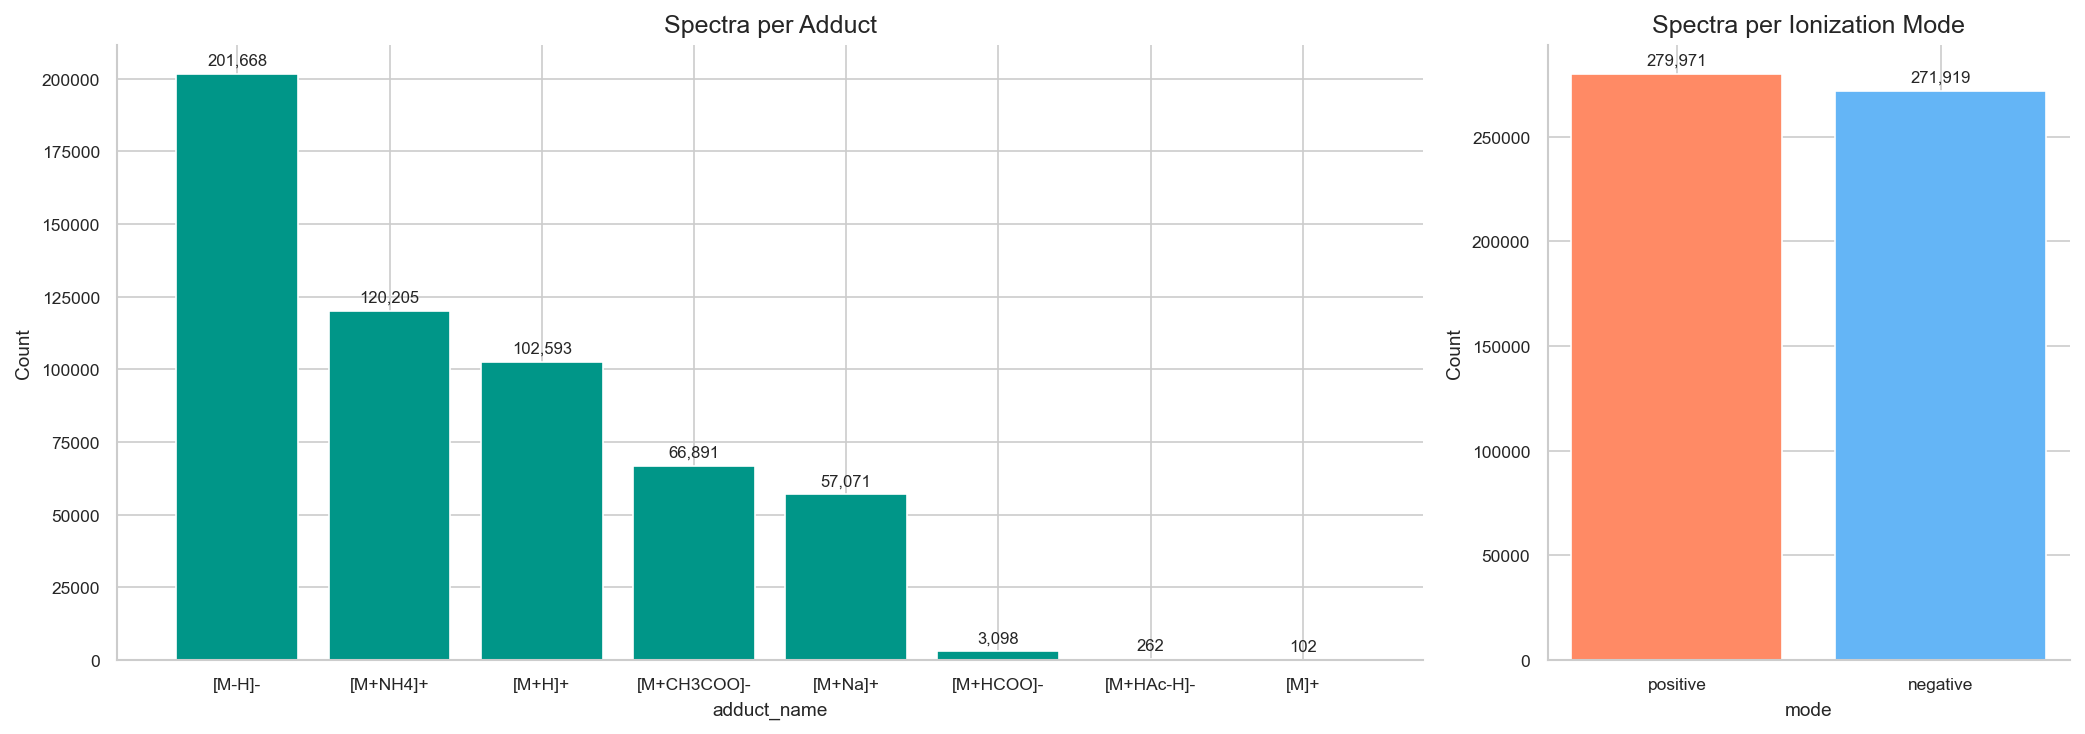

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [2.5, 1]})

# Adduct distribution
ax = axes[0]
adduct_counts = df["adduct_name"].value_counts()
bars = ax.bar(range(len(adduct_counts)), adduct_counts.values, color="#009688", edgecolor="white")
for bar, count in zip(bars, adduct_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(adduct_counts) * 0.01,
            f"{count:,}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(range(len(adduct_counts)))
ax.set_xticklabels(adduct_counts.index, rotation=0)
ax.set_xlabel("adduct_name")
ax.set_ylabel("Count")
ax.set_title("Spectra per Adduct")

# Mode distribution
ax = axes[1]
mode_counts = df["mode"].value_counts()
colors = ["#ff8a65", "#64b5f6"]
bars = ax.bar(range(len(mode_counts)), mode_counts.values, color=colors, edgecolor="white")
for bar, count in zip(bars, mode_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(mode_counts) * 0.01,
            f"{count:,}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(range(len(mode_counts)))
ax.set_xticklabels(mode_counts.index, rotation=0)
ax.set_xlabel("mode")
ax.set_ylabel("Count")
ax.set_title("Spectra per Ionization Mode")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "adduct_mode_distribution.png"), bbox_inches="tight")
plt.show()

## 7. Precursor m/z vs Fragment Count

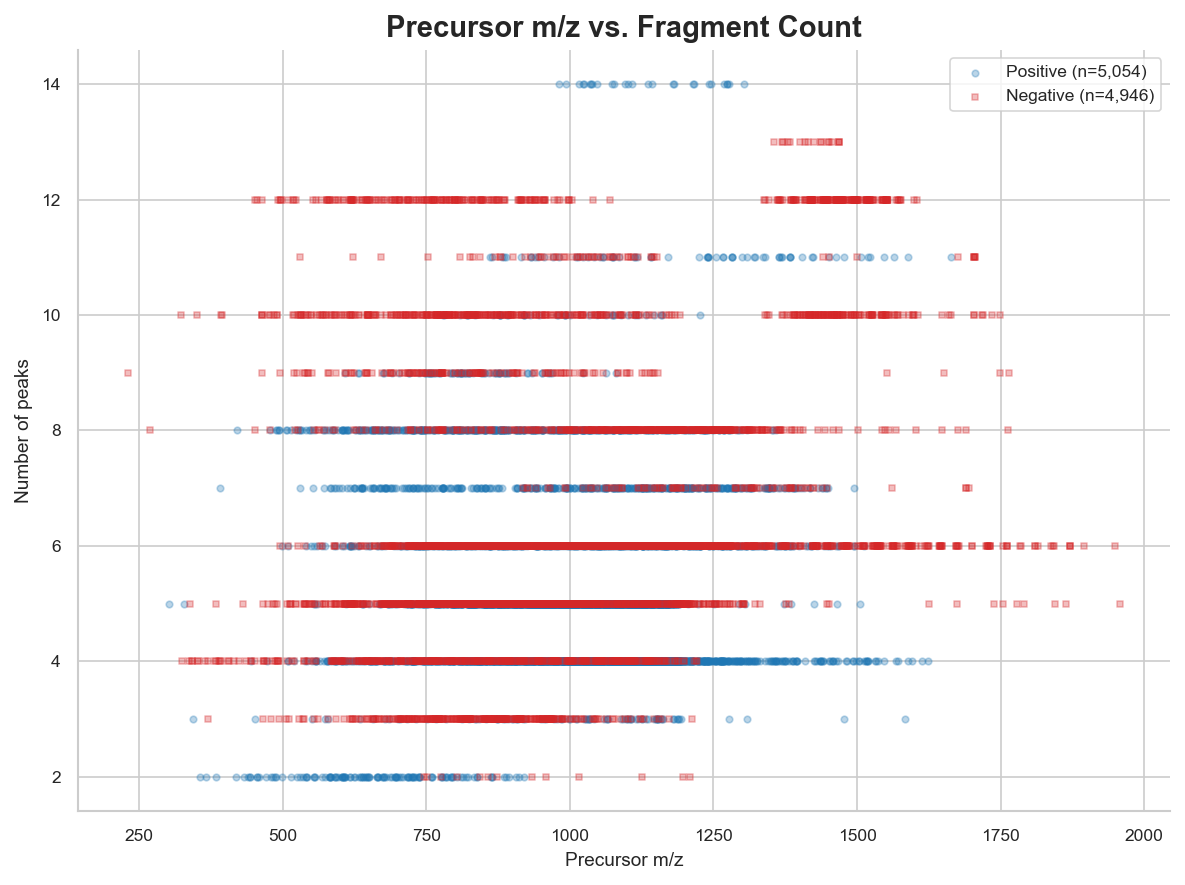

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

sample_size = 10000
if len(df) > sample_size:
    plot_df = df.sample(sample_size, random_state=42)
else:
    plot_df = df

for mode, color, marker in [("positive", "#1f77b4", "o"), ("negative", "#d62728", "s")]:
    subset = plot_df[plot_df["mode"] == mode]
    ax.scatter(subset["precursor_mz"], subset["n_peaks"],
               c=color, alpha=0.3, s=10, label=f"{mode.capitalize()} (n={len(subset):,})",
               marker=marker)

ax.set_xlabel("Precursor m/z")
ax.set_ylabel("Number of peaks")
ax.set_title("Precursor m/z vs. Fragment Count", fontsize=14, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "mz_vs_peaks.png"), bbox_inches="tight")
plt.show()

## 8. Normalization Comparison

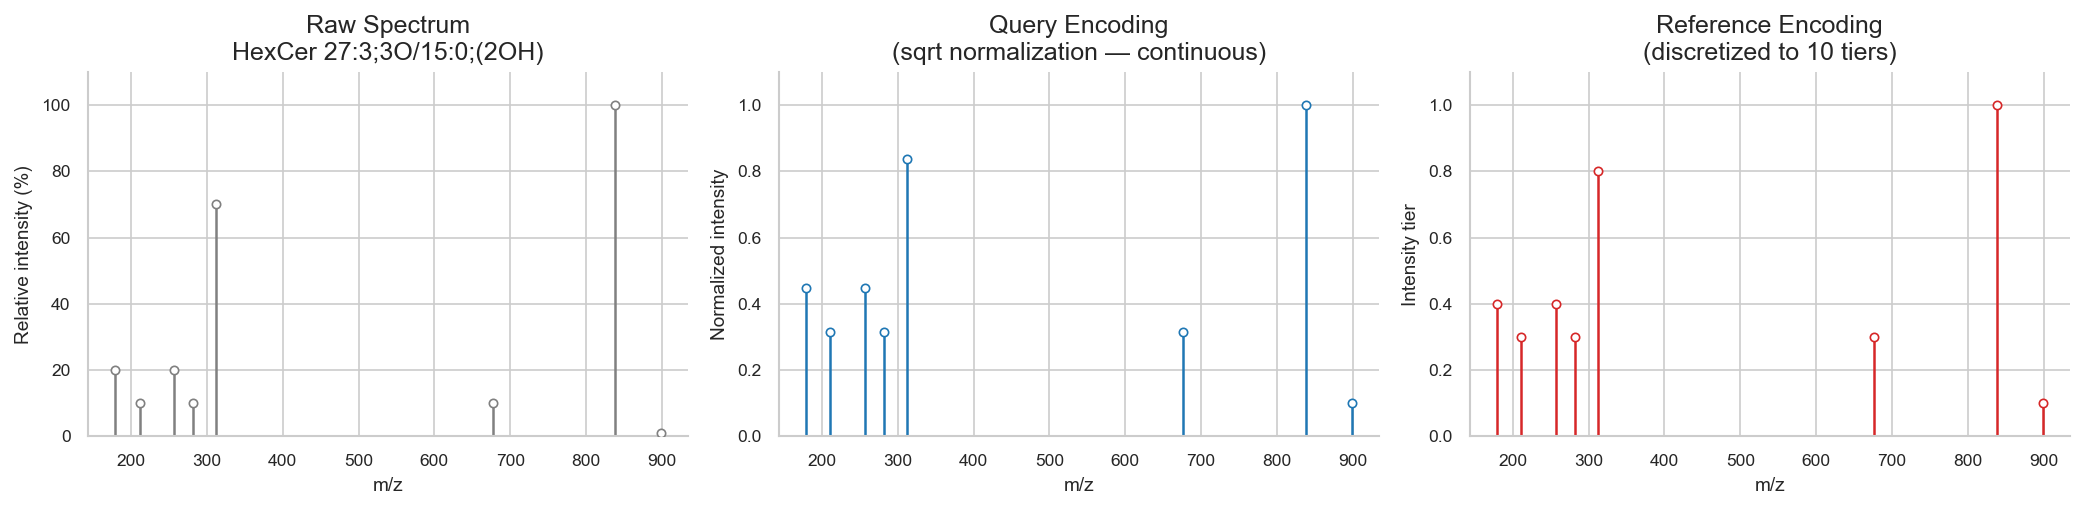

In [9]:
example = df.iloc[0]
mzs = np.asarray(example["mz_list"])
intensities = np.asarray(example["intensity_list"])

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

# Raw spectrum
ax = axes[0]
rel = intensities / intensities.max() * 100 if intensities.max() > 0 else intensities
ax.vlines(mzs, 0, rel, colors="gray", linewidth=1.2)
ax.scatter(mzs, rel, edgecolors="gray", facecolors="white", s=16, linewidths=0.8, zorder=3)
ax.set_xlabel("m/z")
ax.set_ylabel("Relative intensity (%)")
ax.set_title(f"Raw Spectrum\n{example['name']}")
ax.set_ylim(0, 110)

# Sqrt normalization (query encoding)
ax = axes[1]
sqrt_int = np.sqrt(intensities)
sqrt_norm = sqrt_int / sqrt_int.max() if sqrt_int.max() > 0 else sqrt_int
ax.vlines(mzs, 0, sqrt_norm, colors="#1f77b4", linewidth=1.2)
ax.scatter(mzs, sqrt_norm, edgecolors="#1f77b4", facecolors="white", s=16, linewidths=0.8, zorder=3)
ax.set_xlabel("m/z")
ax.set_ylabel("Normalized intensity")
ax.set_title("Query Encoding\n(sqrt normalization \u2014 continuous)")
ax.set_ylim(0, 1.1)

# Discretized to 10 tiers (reference encoding)
ax = axes[2]
tier = np.round(sqrt_norm * 10) / 10
ax.vlines(mzs, 0, tier, colors="#d62728", linewidth=1.2)
ax.scatter(mzs, tier, edgecolors="#d62728", facecolors="white", s=16, linewidths=0.8, zorder=3)
ax.set_xlabel("m/z")
ax.set_ylabel("Intensity tier")
ax.set_title("Reference Encoding\n(discretized to 10 tiers)")
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "normalization_comparison.png"), bbox_inches="tight")
plt.show()

## 9. Intensity Distribution Analysis

/tmp/ipykernel_2481294/2932730254.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(class_data, labels=top_classes_int, patch_artist=True, vert=True)


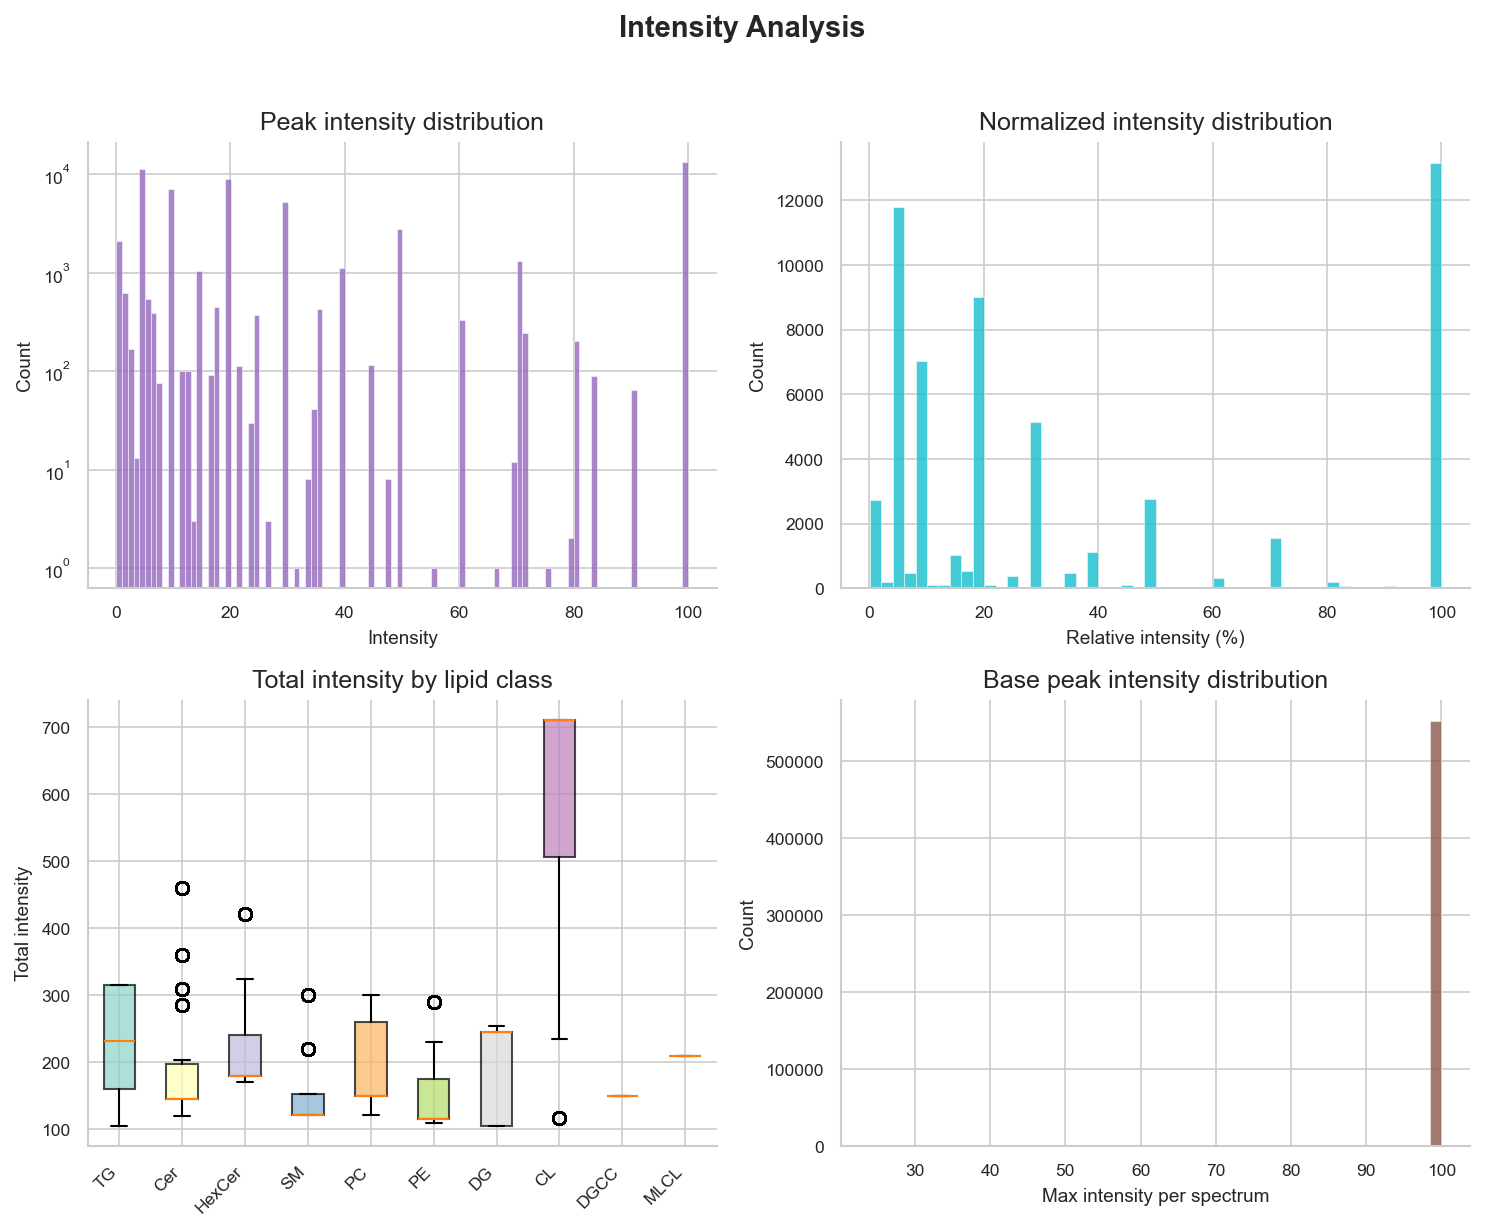

In [10]:
sample_intensities = []
for intensities in df["intensity_list"].sample(min(10000, len(df)), random_state=42):
    sample_intensities.extend(intensities)
sample_intensities = np.array(sample_intensities)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# 1. Raw intensity distribution (log scale)
ax = axes[0, 0]
ax.hist(sample_intensities[sample_intensities > 0], bins=100, alpha=0.8,
        color="#9467bd", edgecolor="white", linewidth=0.3)
ax.set_xlabel("Intensity")
ax.set_ylabel("Count")
ax.set_title("Peak intensity distribution")
ax.set_yscale("log")

# 2. Normalized intensity distribution
ax = axes[0, 1]
normalized_intensities = []
for ints in df["intensity_list"].sample(min(10000, len(df)), random_state=42):
    if max(ints) > 0:
        normalized = [i / max(ints) * 100 for i in ints]
        normalized_intensities.extend(normalized)
ax.hist(normalized_intensities, bins=50, alpha=0.8, color="#17becf",
        edgecolor="white", linewidth=0.3)
ax.set_xlabel("Relative intensity (%)")
ax.set_ylabel("Count")
ax.set_title("Normalized intensity distribution")

# 3. Total intensity per spectrum by lipid class (top 10)
ax = axes[1, 0]
top_classes_int = df["lipid_class"].value_counts().head(10).index
class_data = [df[df["lipid_class"] == c]["total_intensity"] for c in top_classes_int]
bp = ax.boxplot(class_data, labels=top_classes_int, patch_artist=True, vert=True)
colors_bp = plt.cm.Set3(np.linspace(0, 1, len(top_classes_int)))
for patch, color in zip(bp["boxes"], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticklabels(top_classes_int, rotation=45, ha="right")
ax.set_ylabel("Total intensity")
ax.set_title("Total intensity by lipid class")

# 4. Max intensity per spectrum histogram
ax = axes[1, 1]
ax.hist(df["max_intensity"], bins=50, alpha=0.8, color="#8c564b",
        edgecolor="white", linewidth=0.3)
ax.set_xlabel("Max intensity per spectrum")
ax.set_ylabel("Count")
ax.set_title("Base peak intensity distribution")

plt.suptitle("Intensity Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "intensity_distribution.png"), bbox_inches="tight")
plt.show()

## 10. Discrete Intensity Structure

LipidBlast intensities are categorical (~7 dominant tiers: 1, 5, 10, 20, 30, 50, 100) covering >90% of all peaks. This is an in-silico library artifact — real instruments produce continuous signals.

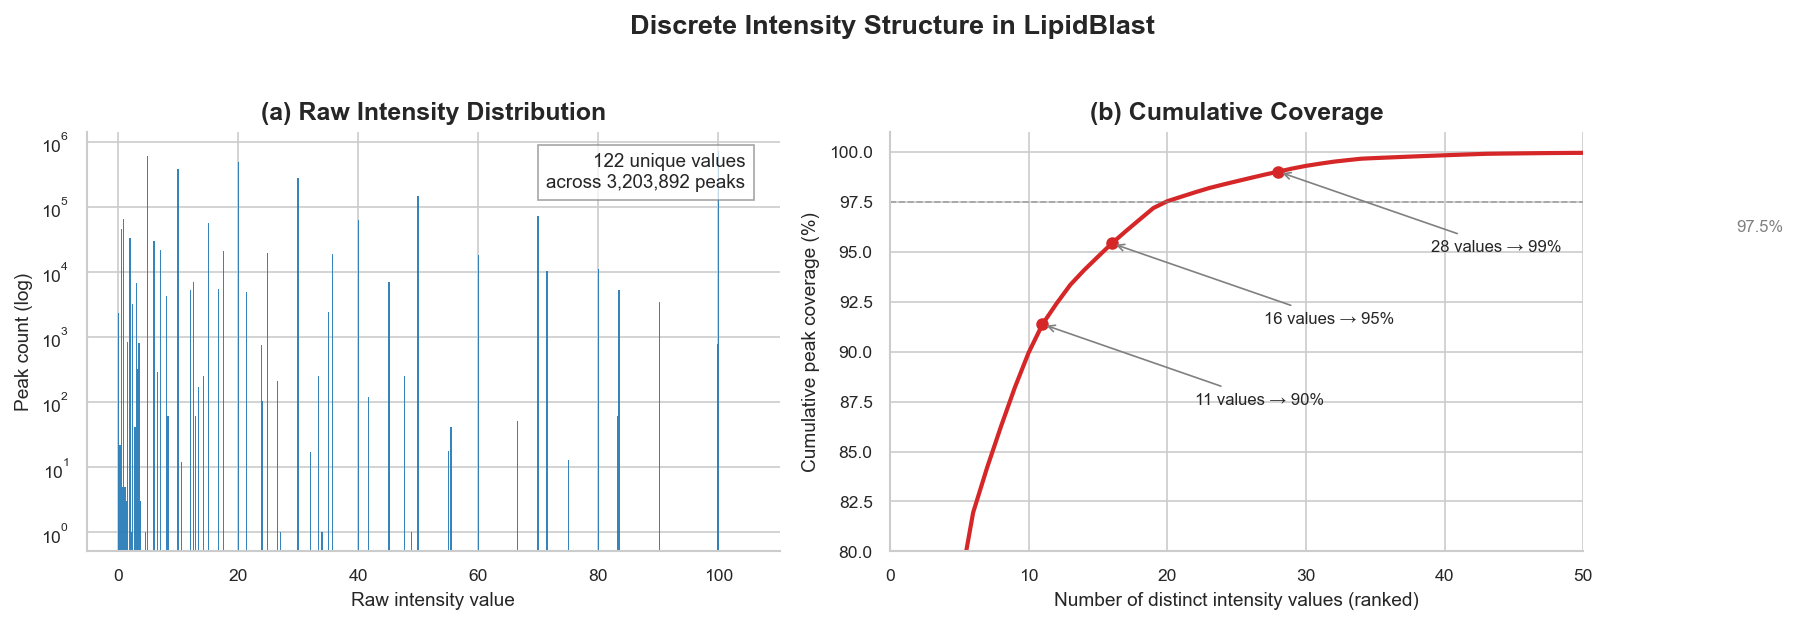

Total peaks: 3,203,892 | Unique intensity values: 122

Top 10 intensity values (approximate tier → count → cumulative %):
  ~100%  (raw   100.0000):  722,684 peaks  (22.6% cumulative)
  ~  5%  (raw     5.0050):  615,063 peaks  (41.8% cumulative)
  ~ 20%  (raw    20.0200):  496,336 peaks  (57.2% cumulative)
  ~ 10%  (raw    10.0100):  387,514 peaks  (69.3% cumulative)
  ~ 30%  (raw    30.0300):  279,670 peaks  (78.1% cumulative)
  ~ 50%  (raw    50.0500):  124,214 peaks  (81.9% cumulative)
  ~ 70%  (raw    70.0701):   71,592 peaks  (84.2% cumulative)
  ~  1%  (raw     1.0010):   66,004 peaks  (86.2% cumulative)
  ~ 40%  (raw    40.0400):   62,605 peaks  (88.2% cumulative)
  ~ 15%  (raw    15.0150):   56,242 peaks  (90.0% cumulative)


In [11]:
from collections import Counter

# Collect all raw intensity values
all_peak_ints = np.concatenate(df["intensity_list"].values)
counts = Counter(all_peak_ints)
n_unique = len(counts)
n_total = len(all_peak_ints)

top_vals = sorted(counts.items(), key=lambda x: -x[1])

# --- Figure 1: discrete spike histogram + cumulative coverage ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) Raw intensity value histogram — reveals the comb structure
ax = axes[0]
bins = np.linspace(0, 105, 500)
ax.hist(all_peak_ints, bins=bins, color="#1f77b4", edgecolor="none", alpha=0.9)
ax.set_yscale("log")
ax.set_xlabel("Raw intensity value")
ax.set_ylabel("Peak count (log)")
ax.set_title("(a) Raw Intensity Distribution", fontweight="bold")
ax.text(0.95, 0.95,
        f"{n_unique} unique values\nacross {n_total:,} peaks",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray"))

# (b) Cumulative coverage by number of distinct values
ax = axes[1]
sorted_counts = np.array([c for _, c in top_vals])
cumulative = np.cumsum(sorted_counts) / n_total * 100
x_vals = np.arange(1, len(cumulative) + 1)

ax.plot(x_vals, cumulative, color="#d62728", linewidth=2)
ax.axhline(97.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.text(len(cumulative) * 0.5, 96, "97.5%", color="gray", fontsize=8)

for threshold in [90, 95, 99]:
    idx_t = np.searchsorted(cumulative, threshold)
    ax.plot(idx_t + 1, cumulative[idx_t], "o", color="#d62728", markersize=5)
    ax.annotate(f"{idx_t + 1} values \u2192 {threshold}%",
                xy=(idx_t + 1, cumulative[idx_t]),
                xytext=(idx_t + 12, cumulative[idx_t] - 4),
                fontsize=8, arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))

ax.set_xlabel("Number of distinct intensity values (ranked)")
ax.set_ylabel("Cumulative peak coverage (%)")
ax.set_title("(b) Cumulative Coverage", fontweight="bold")
ax.set_xlim(0, min(50, len(cumulative)))
ax.set_ylim(80, 101)

plt.suptitle("Discrete Intensity Structure in LipidBlast",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "discrete_intensity_structure.png"), bbox_inches="tight")
plt.show()

# Print the dominant tiers
print(f"Total peaks: {n_total:,} | Unique intensity values: {n_unique}")
print(f"\nTop 10 intensity values (approximate tier \u2192 count \u2192 cumulative %):")
running = 0
for val, cnt in top_vals[:10]:
    running += cnt
    tier = round(val)
    print(f"  ~{tier:>3d}%  (raw {val:>10.4f}):  {cnt:>7,} peaks  ({running/n_total*100:.1f}% cumulative)")

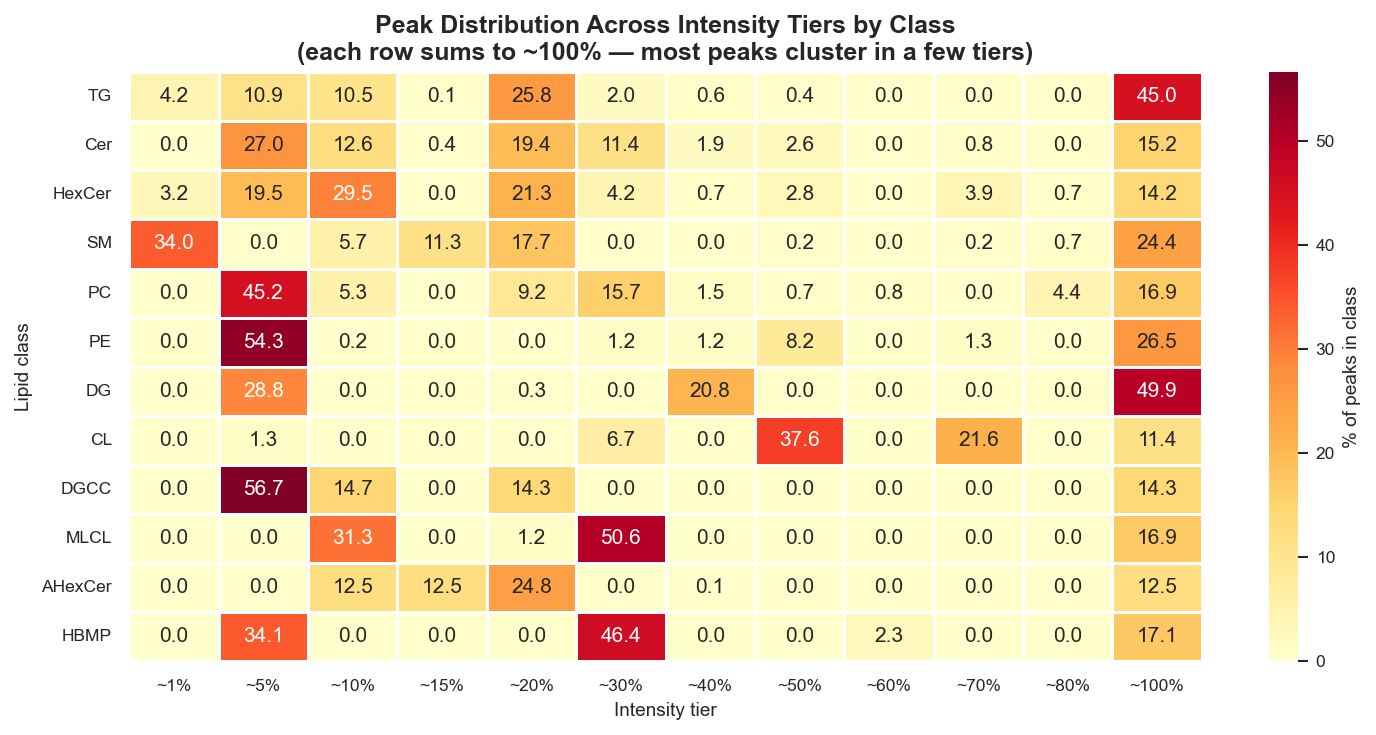

In [12]:
# Figure 2: per-class intensity tier heatmap
# Round each raw value to its intended tier and show frequency by lipid class

tier_labels = [1, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 100]

top12_classes = df["lipid_class"].value_counts().head(12).index.tolist()
heatmap_data = []

for cls in top12_classes:
    cls_ints = np.concatenate(df.loc[df["lipid_class"] == cls, "intensity_list"].values)
    cls_rel = cls_ints  # already stored as relative (max = 100)
    rounded = np.round(cls_rel).astype(int)
    cls_counts = Counter(rounded)
    total = len(cls_ints)
    row = [cls_counts.get(t, 0) / total * 100 for t in tier_labels]
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data, index=top12_classes,
                          columns=[f"~{t}%" for t in tier_labels])

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heatmap_df, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "% of peaks in class"}, ax=ax)
ax.set_xlabel("Intensity tier")
ax.set_ylabel("Lipid class")
ax.set_title("Peak Distribution Across Intensity Tiers by Class\n"
             "(each row sums to ~100% — most peaks cluster in a few tiers)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "intensity_tier_heatmap.png"), bbox_inches="tight")
plt.show()

del all_peak_ints, counts, top_vals

## 11. Precursor vs Fragment m/z Heatmap

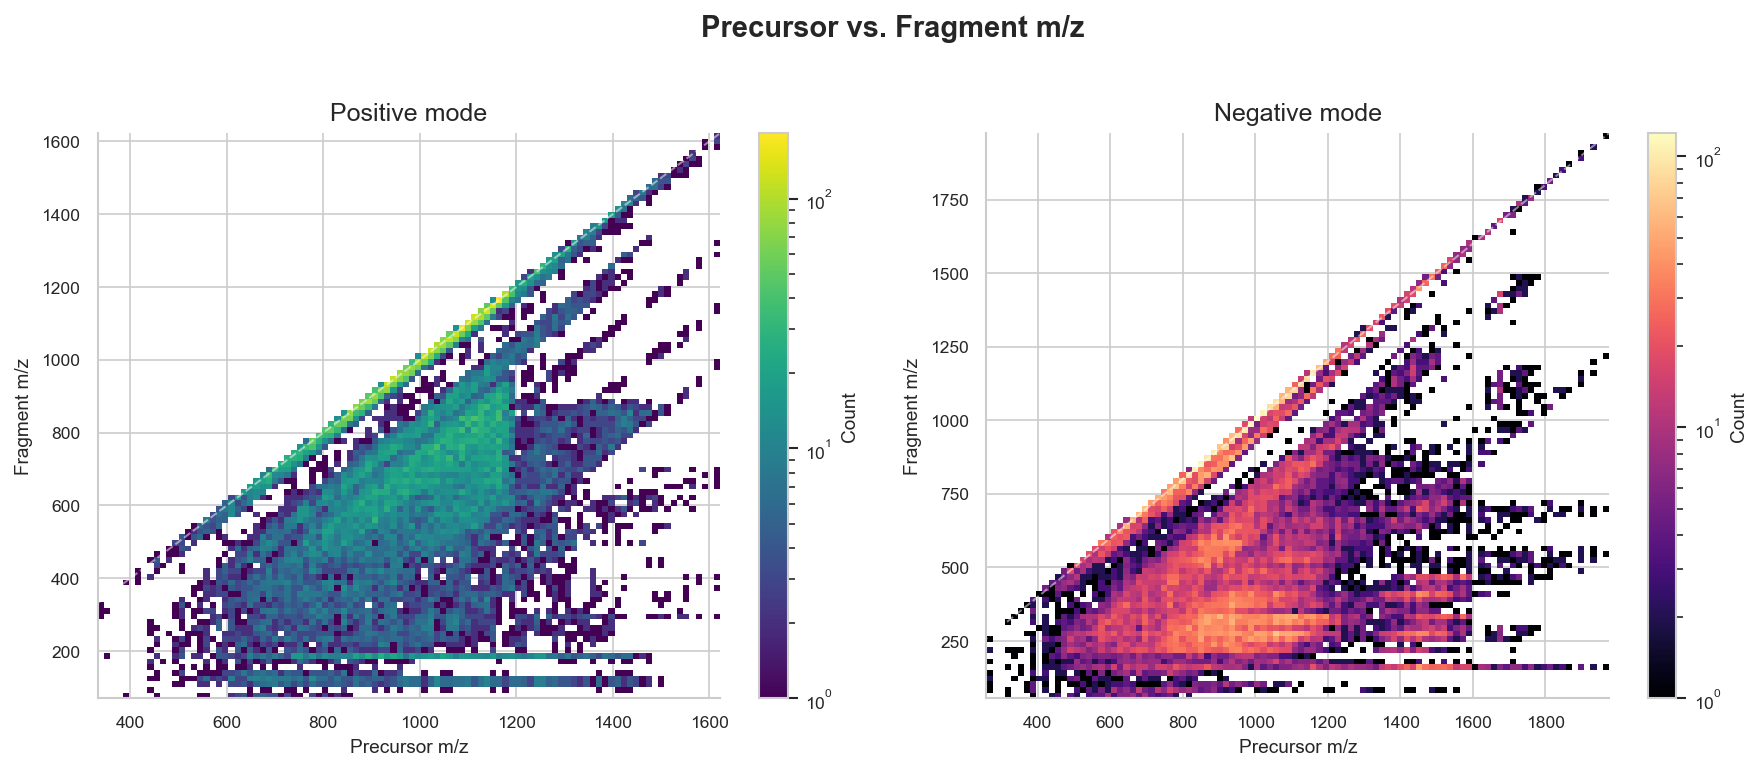

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sample_size_hm = 5000

for ax, mode in zip(axes, ["positive", "negative"]):
    subset = df[df["mode"] == mode]
    if len(subset) > sample_size_hm:
        subset = subset.sample(sample_size_hm, random_state=42)

    precursor_mzs = []
    fragment_mzs = []
    for _, row in subset.iterrows():
        for frag_mz in row["mz_list"]:
            precursor_mzs.append(row["precursor_mz"])
            fragment_mzs.append(frag_mz)

    h = ax.hist2d(precursor_mzs, fragment_mzs, bins=100,
                  cmap="viridis" if mode == "positive" else "magma",
                  norm=plt.matplotlib.colors.LogNorm())
    plt.colorbar(h[3], ax=ax, label="Count")

    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'w--', alpha=0.5, linewidth=1, label="Precursor = Fragment")

    ax.set_xlabel("Precursor m/z")
    ax.set_ylabel("Fragment m/z")
    ax.set_title(f"{mode.capitalize()} mode")

plt.suptitle("Precursor vs. Fragment m/z", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "precursor_fragment_heatmap.png"), bbox_inches="tight")
plt.show()

## 12. Degeneracy / Template Collapse Analysis

Overall: 551,890 spectra -> 422 unique templates


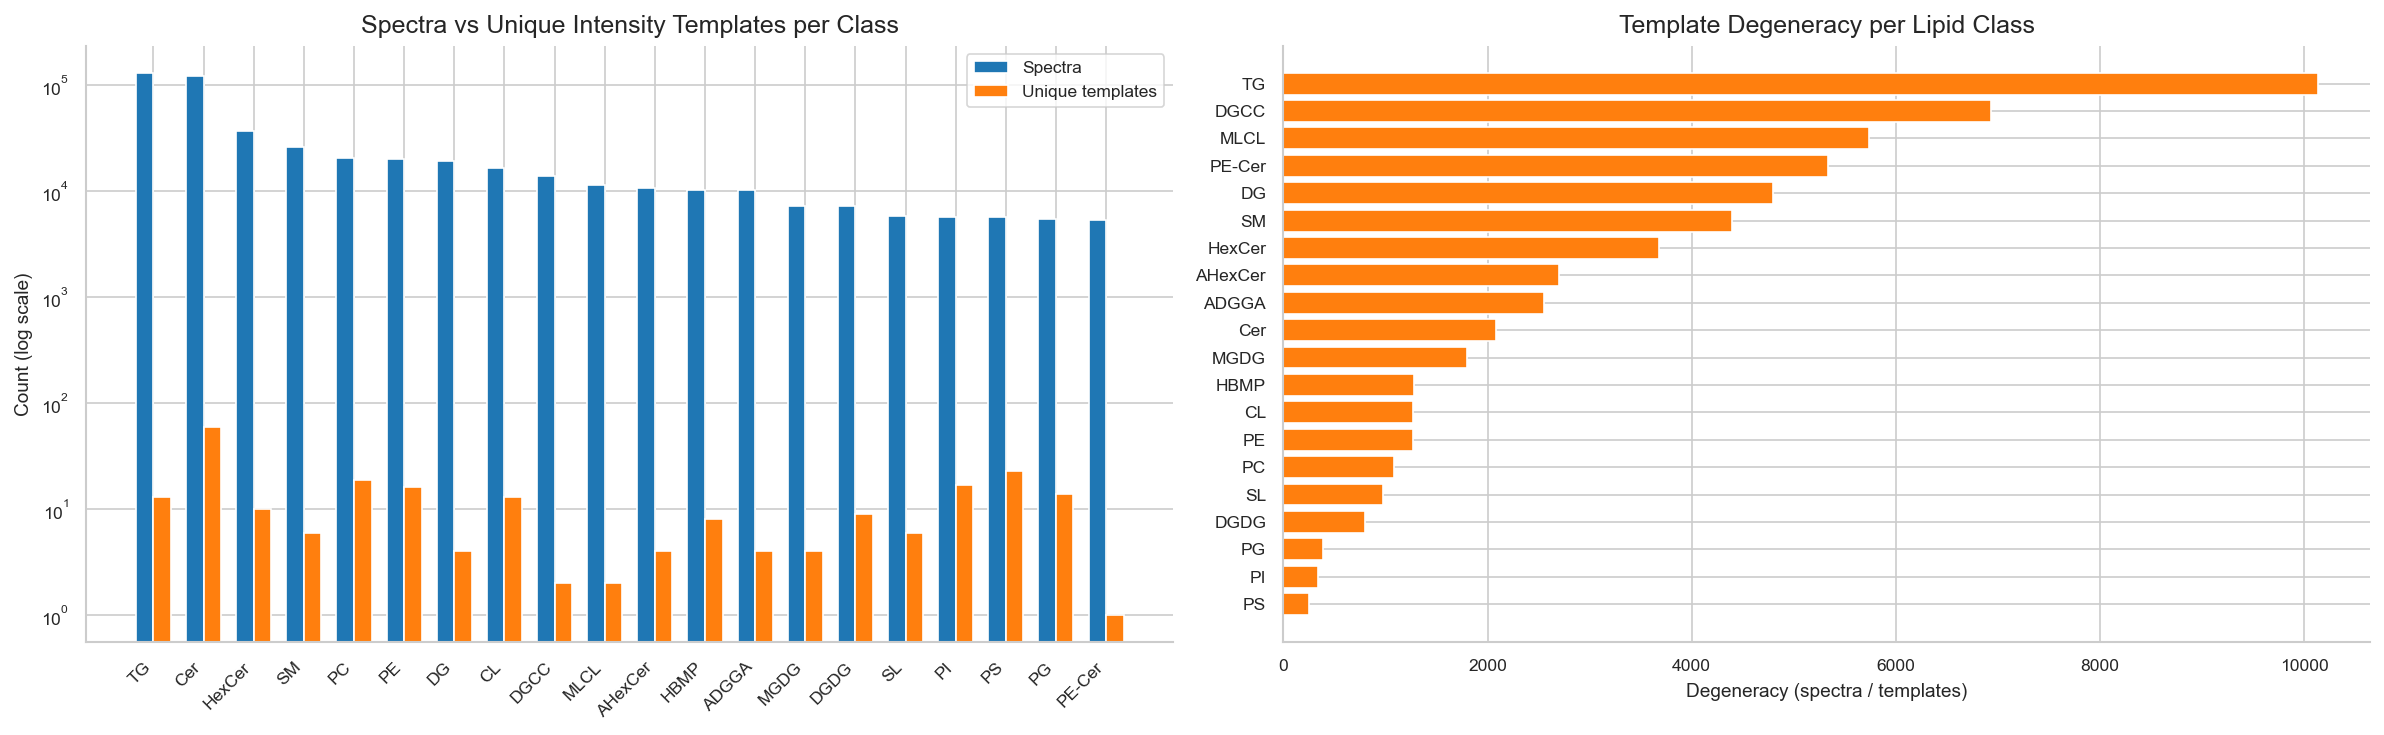

In [14]:
def intensity_template_key(intensities):
    """Hashable representation of normalized intensity pattern."""
    arr = np.asarray(intensities, dtype=np.float64)
    if arr.max() > 0:
        arr = arr / arr.max()
    return tuple(np.round(arr, 6))

df["_template_key"] = df["intensity_list"].apply(intensity_template_key)

# Per-(class, adduct) stats
group_stats = df.groupby(["lipid_class", "adduct_name"]).agg(
    n_spectra=("name", "size"),
    n_templates=("_template_key", "nunique"),
    n_compounds=("inchikey", "nunique"),
).reset_index()
group_stats["compression"] = group_stats["n_spectra"] / group_stats["n_templates"]

# Per-class aggregation for the figure
class_stats = df.groupby("lipid_class").agg(
    n_spectra=("name", "size"),
    n_templates=("_template_key", "nunique"),
).reset_index()
class_stats["degeneracy"] = class_stats["n_spectra"] / class_stats["n_templates"]
class_stats = class_stats.sort_values("n_spectra", ascending=False)

print(f"Overall: {len(df):,} spectra -> {df['_template_key'].nunique():,} unique templates")

top20 = class_stats.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: grouped bars — spectra vs templates (log scale)
ax = axes[0]
x = np.arange(len(top20))
w = 0.35
ax.bar(x - w / 2, top20["n_spectra"].values, w, color="#1f77b4", label="Spectra")
ax.bar(x + w / 2, top20["n_templates"].values, w, color="#ff7f0e", label="Unique templates")
ax.set_xticks(x)
ax.set_xticklabels(top20["lipid_class"].values, rotation=45, ha="right")
ax.set_ylabel("Count (log scale)")
ax.set_yscale("log")
ax.set_title("Spectra vs Unique Intensity Templates per Class")
ax.legend()

# Right: horizontal bars — degeneracy ratio
ax = axes[1]
ordered = top20.sort_values("degeneracy", ascending=True)
ax.barh(range(len(ordered)), ordered["degeneracy"].values, color="#ff7f0e")
ax.set_yticks(range(len(ordered)))
ax.set_yticklabels(ordered["lipid_class"].values)
ax.set_xlabel("Degeneracy (spectra / templates)")
ax.set_title("Template Degeneracy per Lipid Class")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "degeneracy_analysis.png"), bbox_inches="tight")
plt.show()

## 13. Template Collapse Proof

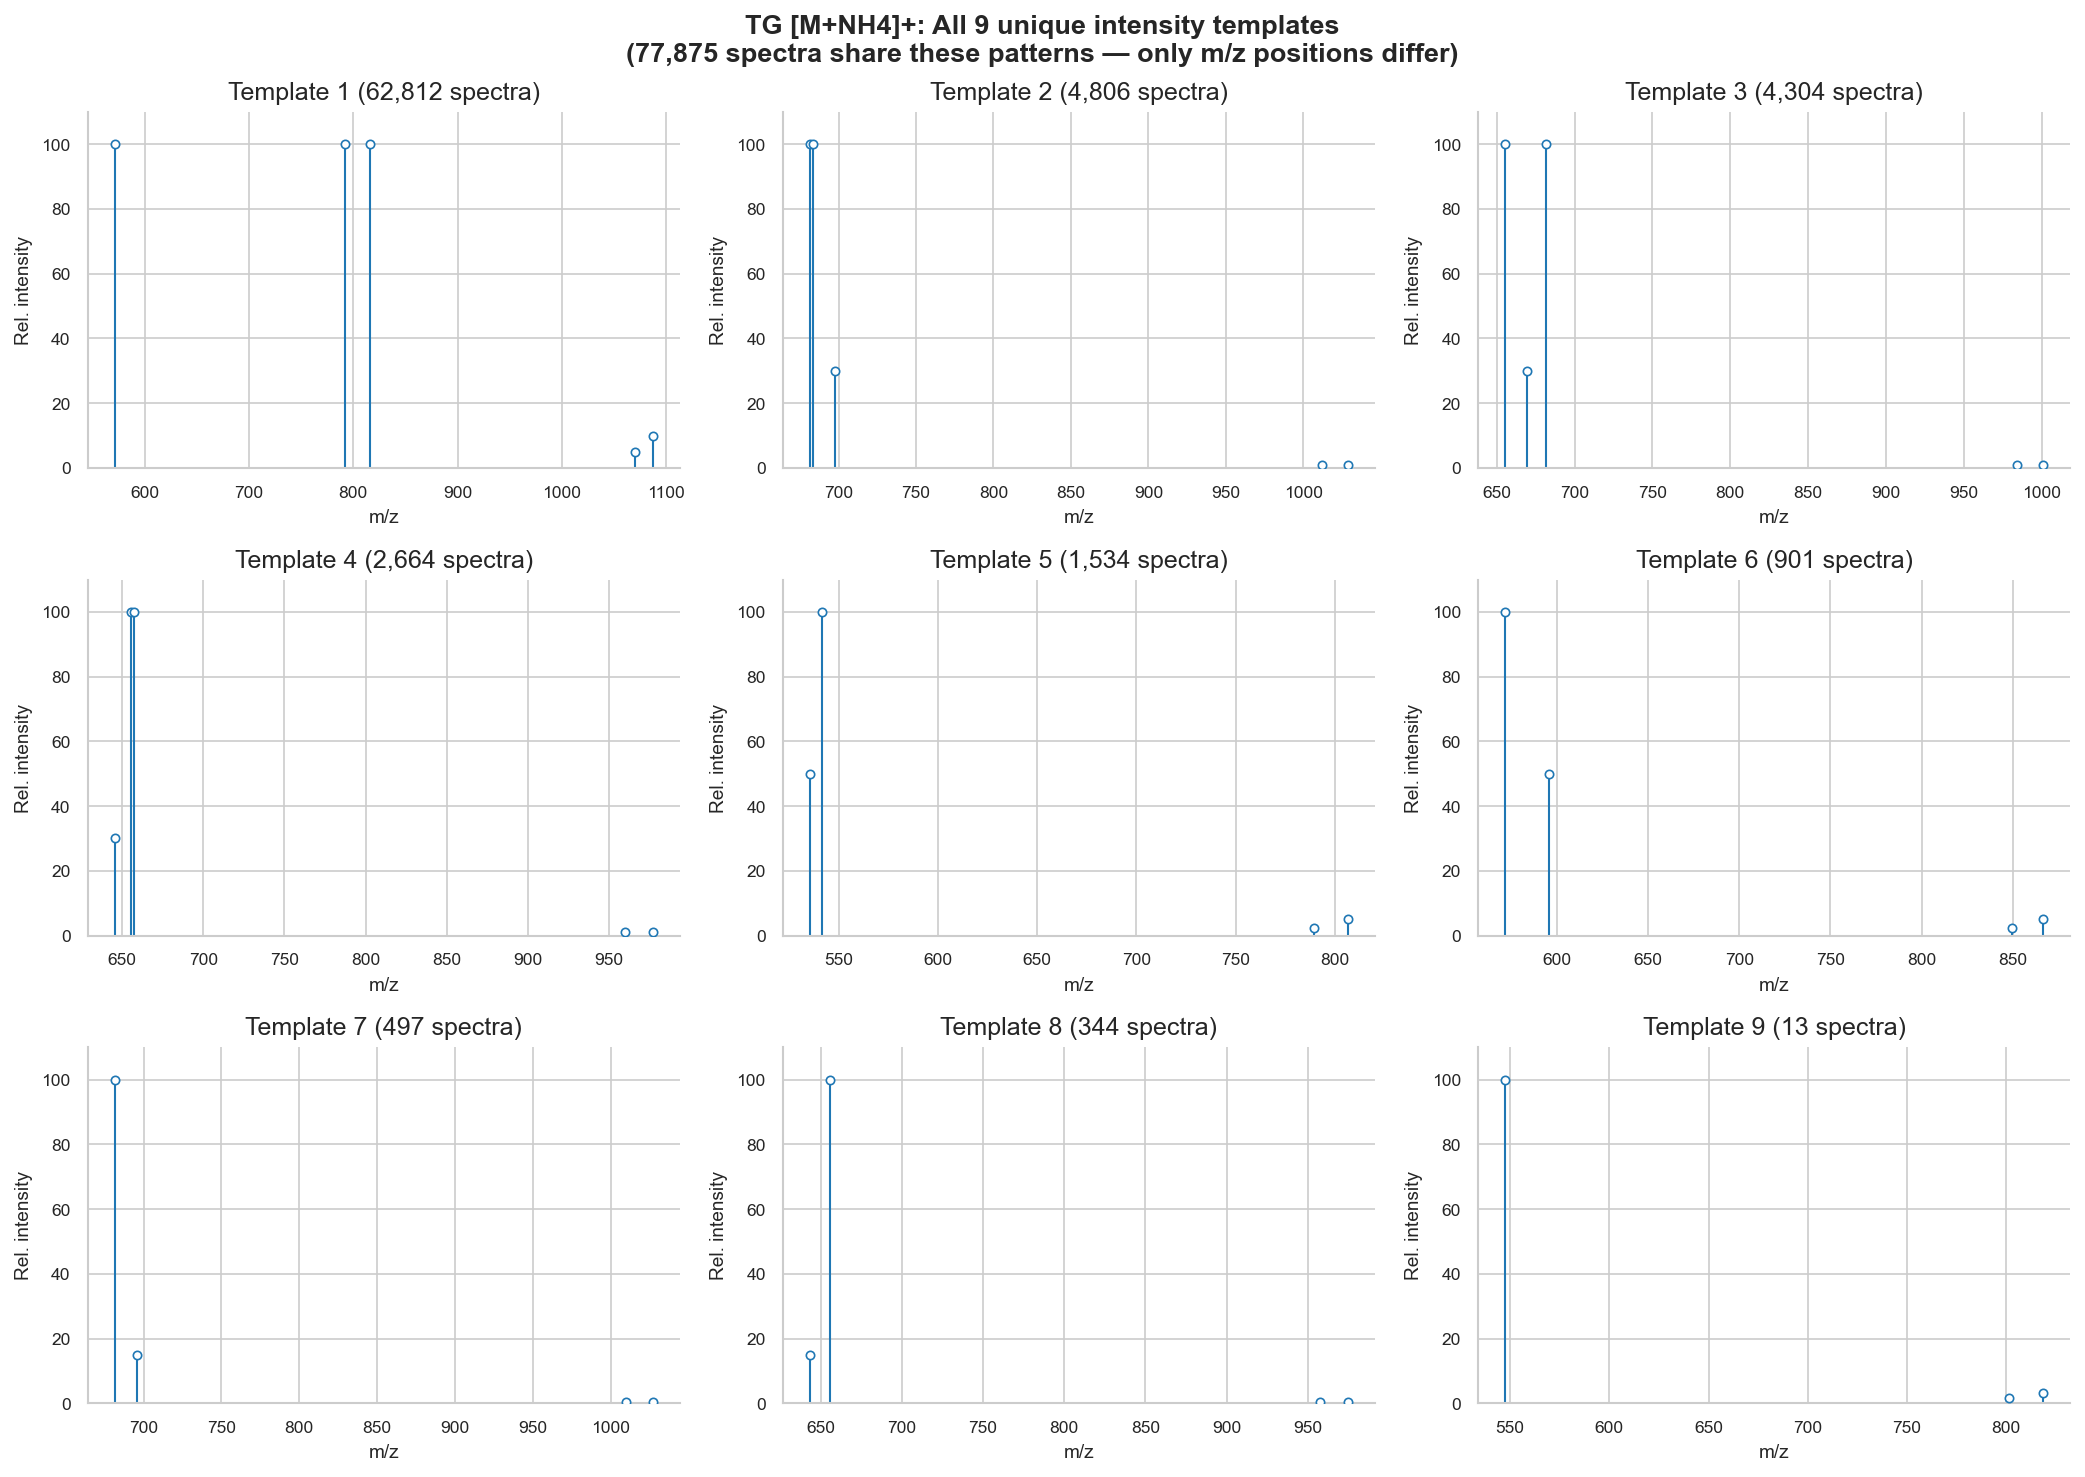

In [15]:
# Show all 9 unique templates for TG [M+NH4]+
tg_nh4 = df[(df["lipid_class"] == "TG") & (df["adduct_name"] == "[M+NH4]+")]
template_counts = tg_nh4["_template_key"].value_counts()
n_total = len(tg_nh4)

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle(
    f"TG [M+NH4]+: All {len(template_counts)} unique intensity templates\n"
    f"({n_total:,} spectra share these patterns \u2014 only m/z positions differ)",
    fontsize=13, fontweight="bold",
)

for idx, (ax, (template, count)) in enumerate(zip(axes.flatten(), template_counts.items())):
    example_row = tg_nh4[tg_nh4["_template_key"] == template].iloc[0]
    mzs = np.asarray(example_row["mz_list"])
    ints = np.asarray(example_row["intensity_list"])
    rel = ints / ints.max() * 100 if ints.max() > 0 else ints

    ax.vlines(mzs, 0, rel, colors="#1f77b4", linewidth=1)
    ax.scatter(mzs, rel, edgecolors="#1f77b4", facecolors="white", s=16, linewidths=0.8, zorder=3)
    ax.set_xlabel("m/z")
    ax.set_ylabel("Rel. intensity")
    ax.set_title(f"Template {idx + 1} ({count:,} spectra)")
    ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "template_collapse_proof.png"), bbox_inches="tight")
plt.show()

## 14. Same Template, Different m/z

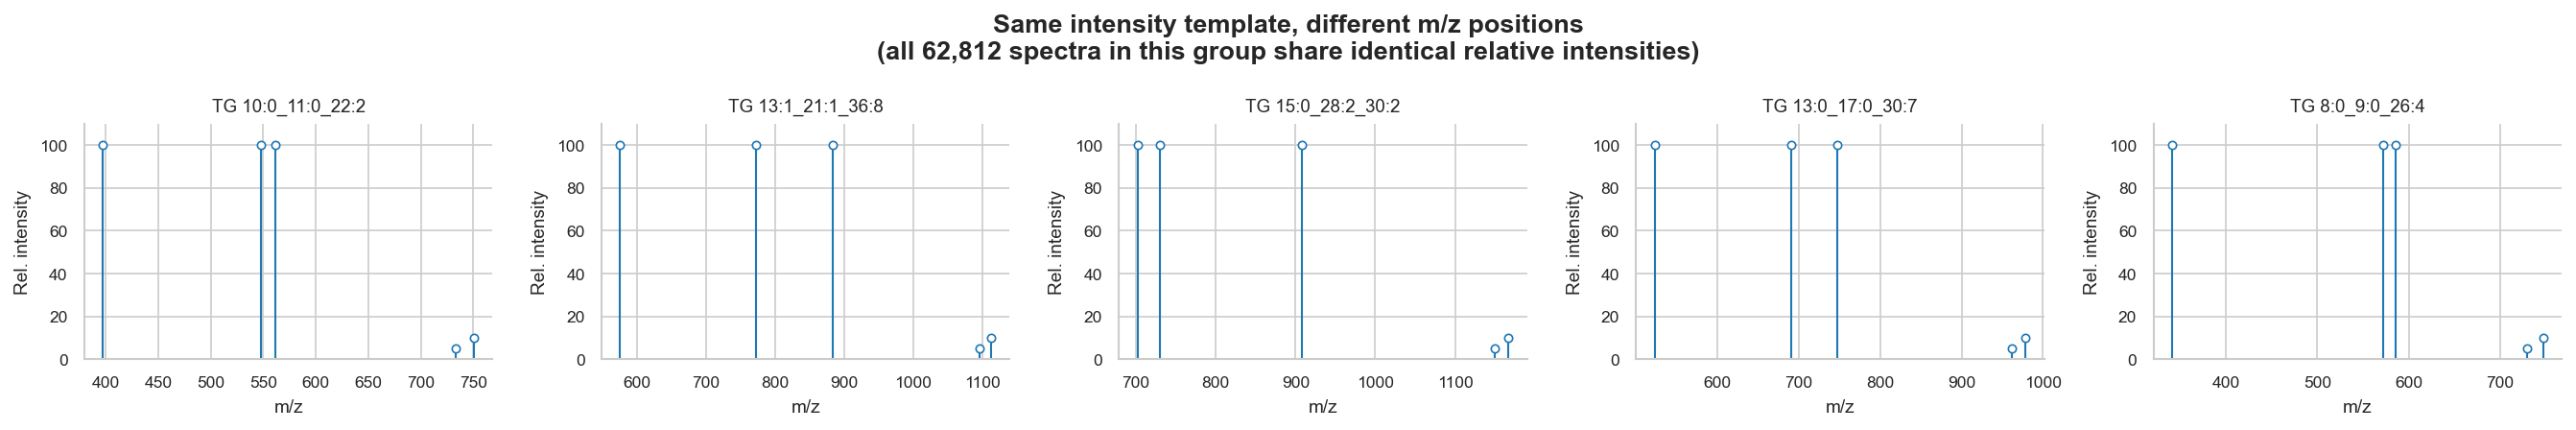

In [16]:
# Pick the most common template from TG [M+NH4]+
most_common_template = template_counts.index[0]
same_template = tg_nh4[tg_nh4["_template_key"] == most_common_template]
n_same = len(same_template)

samples = same_template.sample(5, random_state=42)

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
fig.suptitle(
    f"Same intensity template, different m/z positions\n"
    f"(all {n_same:,} spectra in this group share identical relative intensities)",
    fontsize=13, fontweight="bold",
)

for ax, (_, row) in zip(axes, samples.iterrows()):
    mzs = np.asarray(row["mz_list"])
    ints = np.asarray(row["intensity_list"])
    rel = ints / ints.max() * 100 if ints.max() > 0 else ints
    ax.vlines(mzs, 0, rel, colors="#1f77b4", linewidth=1)
    ax.scatter(mzs, rel, edgecolors="#1f77b4", facecolors="white", s=16, linewidths=0.8, zorder=3)
    ax.set_xlabel("m/z")
    ax.set_ylabel("Rel. intensity")
    short_name = row["name"].replace(" ", " ").replace("/", "_").replace(";", "_")
    ax.set_title(short_name, fontsize=9)
    ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "same_template_different_mz.png"), bbox_inches="tight")
plt.show()

## 15. Positional Isomer Analysis

Positional isomers (same formula + adduct) have identical precursor m/z and byte-identical fragment spectra — completely indistinguishable by any spectral similarity method.

Isomer groups (same formula + adduct + mode, >1 member): 19,932
Spectra in isomer groups: 544,637 / 551,890 (98.7%)
Group sizes: min=2, max=676, mean=27.3, median=12



Spot-check: 1/200 groups have byte-identical spectra (0%)

Top 10 largest isomer groups:
  C64H123NO5 [M-H]- (negative): 676 members
    - Cer 30:1;2O/12:0;O(FA 22:1)
    - Cer 30:1;2O/12:1;O(FA 22:0)
    - Cer 30:1;2O/13:0;O(FA 21:1)
    ... and 673 more
  C65H125NO5 [M-H]- (negative): 673 members
    - Cer 30:1;2O/13:0;O(FA 22:1)
    - Cer 30:1;2O/13:1;O(FA 22:0)
    - Cer 30:1;2O/14:0;O(FA 21:1)
    ... and 670 more
  C66H127NO5 [M-H]- (negative): 672 members
    - Cer 30:1;2O/14:0;O(FA 22:1)
    - Cer 30:1;2O/14:1;O(FA 22:0)
    - Cer 30:1;2O/15:0;O(FA 21:1)
    ... and 669 more
  C63H121NO5 [M-H]- (negative): 669 members
    - Cer 30:1;2O/12:0;O(FA 21:1)
    - Cer 30:1;2O/12:1;O(FA 21:0)
    - Cer 30:1;2O/13:0;O(FA 20:1)
    ... and 666 more
  C67H129NO5 [M-H]- (negative): 664 members
    - Cer 30:1;2O/15:0;O(FA 22:1)
    - Cer 30:1;2O/15:1;O(FA 22:0)
    - Cer 30:1;2O/16:0;O(FA 21:1)
    ... and 661 more
  C62H119NO5 [M-H]- (negative): 660 members
    - Cer 30:1;2O/12:0;O(FA 20:

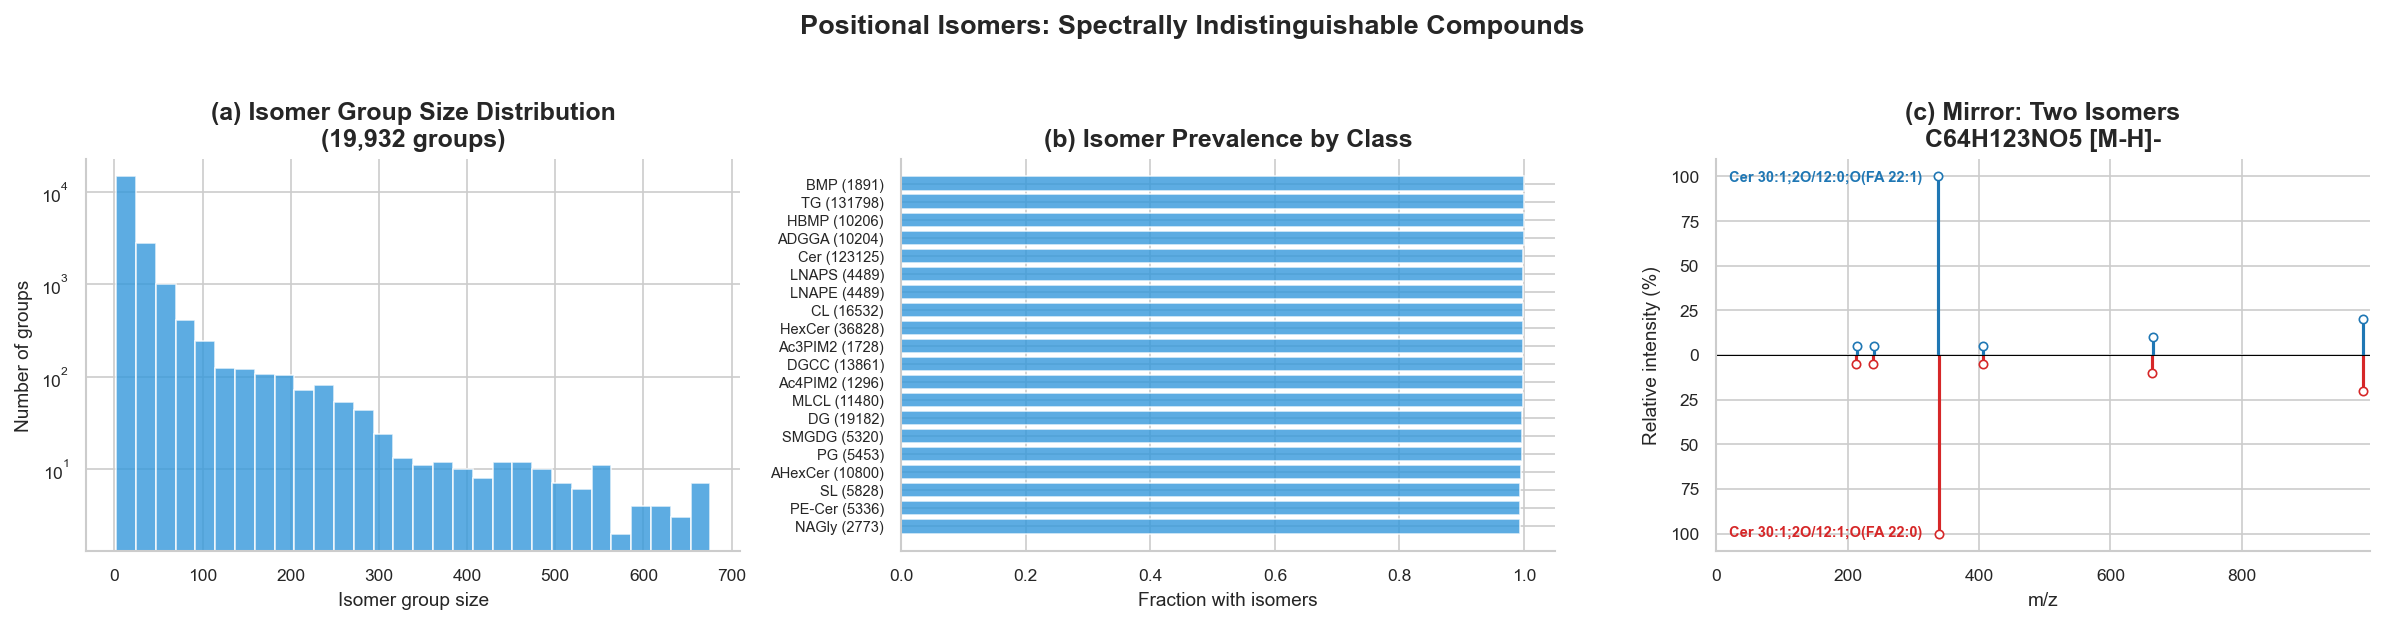

In [17]:
# Group by (formula, adduct, mode) — same formula + same adduct guarantees same precursor_mz
isomer_groups = df.groupby(["formula", "adduct_name", "mode"])["name"].agg(list)
isomer_groups = isomer_groups[isomer_groups.apply(len) > 1]

n_groups = len(isomer_groups)
n_spectra_in_groups = isomer_groups.apply(len).sum()
group_sizes = isomer_groups.apply(len)

print(f"Isomer groups (same formula + adduct + mode, >1 member): {n_groups:,}")
print(f"Spectra in isomer groups: {n_spectra_in_groups:,} / {len(df):,} ({n_spectra_in_groups/len(df):.1%})")
print(f"Group sizes: min={group_sizes.min()}, max={group_sizes.max()}, "
      f"mean={group_sizes.mean():.1f}, median={group_sizes.median():.0f}")

# Verify spectra are truly identical within groups (spot-check 200 groups)
def _spectra_identical(members):
    ref_mz = np.asarray(members.iloc[0]["mz_list"])
    ref_int = np.asarray(members.iloc[0]["intensity_list"])
    for _, row in members.iloc[1:].iterrows():
        other_mz = np.asarray(row["mz_list"])
        other_int = np.asarray(row["intensity_list"])
        if len(ref_mz) != len(other_mz):
            return False
        if not (np.allclose(ref_mz, other_mz) and np.allclose(ref_int, other_int)):
            return False
    return True

rng = np.random.default_rng(42)
sample_keys = rng.choice(len(isomer_groups), min(200, len(isomer_groups)), replace=False)
n_checked, n_identical = 0, 0
for idx in sample_keys:
    names = isomer_groups.iloc[idx]
    members = df[df["name"].isin(names)]
    n_checked += 1
    n_identical += int(_spectra_identical(members))
print(f"\nSpot-check: {n_identical}/{n_checked} groups have byte-identical spectra ({n_identical/n_checked:.0%})")

# Top 10 largest isomer groups
print("\nTop 10 largest isomer groups:")
top10_groups = isomer_groups.sort_values(key=lambda x: x.apply(len), ascending=False).head(10)
for (formula, adduct, mode), names in top10_groups.items():
    print(f"  {formula} {adduct} ({mode}): {len(names)} members")
    for name in names[:3]:
        print(f"    - {name}")
    if len(names) > 3:
        print(f"    ... and {len(names) - 3} more")

# --- Figures ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Group size distribution — log scale to show the long tail
ax = axes[0]
ax.hist(group_sizes, bins=30, alpha=0.8,
        color="#3498db", edgecolor="white")
ax.set_yscale("log")
ax.set_xlabel("Isomer group size")
ax.set_ylabel("Number of groups")
ax.set_title(f"(a) Isomer Group Size Distribution\n({n_groups:,} groups)", fontweight="bold")

# (b) Fraction of library affected per lipid class
isomer_names = set()
for names in isomer_groups:
    isomer_names.update(names)
df["_is_isomer"] = df["name"].isin(isomer_names)
class_isomer = df.groupby("lipid_class")["_is_isomer"].agg(["mean", "size"]).sort_values("mean", ascending=False)
class_isomer = class_isomer[class_isomer["size"] >= 10].head(20)

ax = axes[1]
ax.barh(range(len(class_isomer)), class_isomer["mean"], color="#3498db", alpha=0.8)
ax.set_yticks(range(len(class_isomer)))
ax.set_yticklabels([f"{c} ({int(n)})" for c, n in zip(class_isomer.index, class_isomer["size"])],
                    fontsize=7)
ax.set_xlabel("Fraction with isomers")
ax.set_title("(b) Isomer Prevalence by Class", fontweight="bold")
ax.invert_yaxis()
df.drop(columns=["_is_isomer"], inplace=True)

# (c) Mirror plot: two isomers from the same group
import matplotlib.ticker as ticker

example_group = top10_groups.iloc[0]
example_members = df[df["name"].isin(example_group)]
iso_a = example_members.iloc[0]
iso_b = example_members.iloc[1]

ax = axes[2]
mzs_a = np.asarray(iso_a["mz_list"])
ints_a = np.asarray(iso_a["intensity_list"])
rel_a = ints_a / ints_a.max() * 100 if ints_a.max() > 0 else ints_a

mzs_b = np.asarray(iso_b["mz_list"])
ints_b = np.asarray(iso_b["intensity_list"])
rel_b = ints_b / ints_b.max() * 100 if ints_b.max() > 0 else ints_b

ax.vlines(mzs_a, 0, rel_a, colors="#1f77b4", linewidth=1.5)
ax.scatter(mzs_a, rel_a, edgecolors="#1f77b4", facecolors="white", s=16, linewidths=0.8, zorder=3)
ax.vlines(mzs_b, 0, -rel_b, colors="#d62728", linewidth=1.5)
ax.scatter(mzs_b, -rel_b, edgecolors="#d62728", facecolors="white", s=16, linewidths=0.8, zorder=3)

ax.axhline(0, color="black", linewidth=0.5)

@ticker.FuncFormatter
def abs_formatter(x, _pos):
    return str(int(abs(x)))
ax.yaxis.set_major_formatter(abs_formatter)

ax.text(0.02, 0.97, iso_a["name"][:40], transform=ax.transAxes, fontsize=7,
        va="top", color="#1f77b4", fontweight="bold")
ax.text(0.02, 0.03, iso_b["name"][:40], transform=ax.transAxes, fontsize=7,
        va="bottom", color="#d62728", fontweight="bold")

ax.set_xlabel("m/z")
ax.set_ylabel("Relative intensity (%)")
formula, adduct, mode = top10_groups.index[0]
ax.set_title(f"(c) Mirror: Two Isomers\n{formula} {adduct}", fontweight="bold")
ax.set_xlim(0, max(mzs_a.max(), mzs_b.max()) + 10)

plt.suptitle("Positional Isomers: Spectrally Indistinguishable Compounds",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "positional_isomer_analysis.png"), bbox_inches="tight")
plt.show()

## 16. Example MS2 Spectra

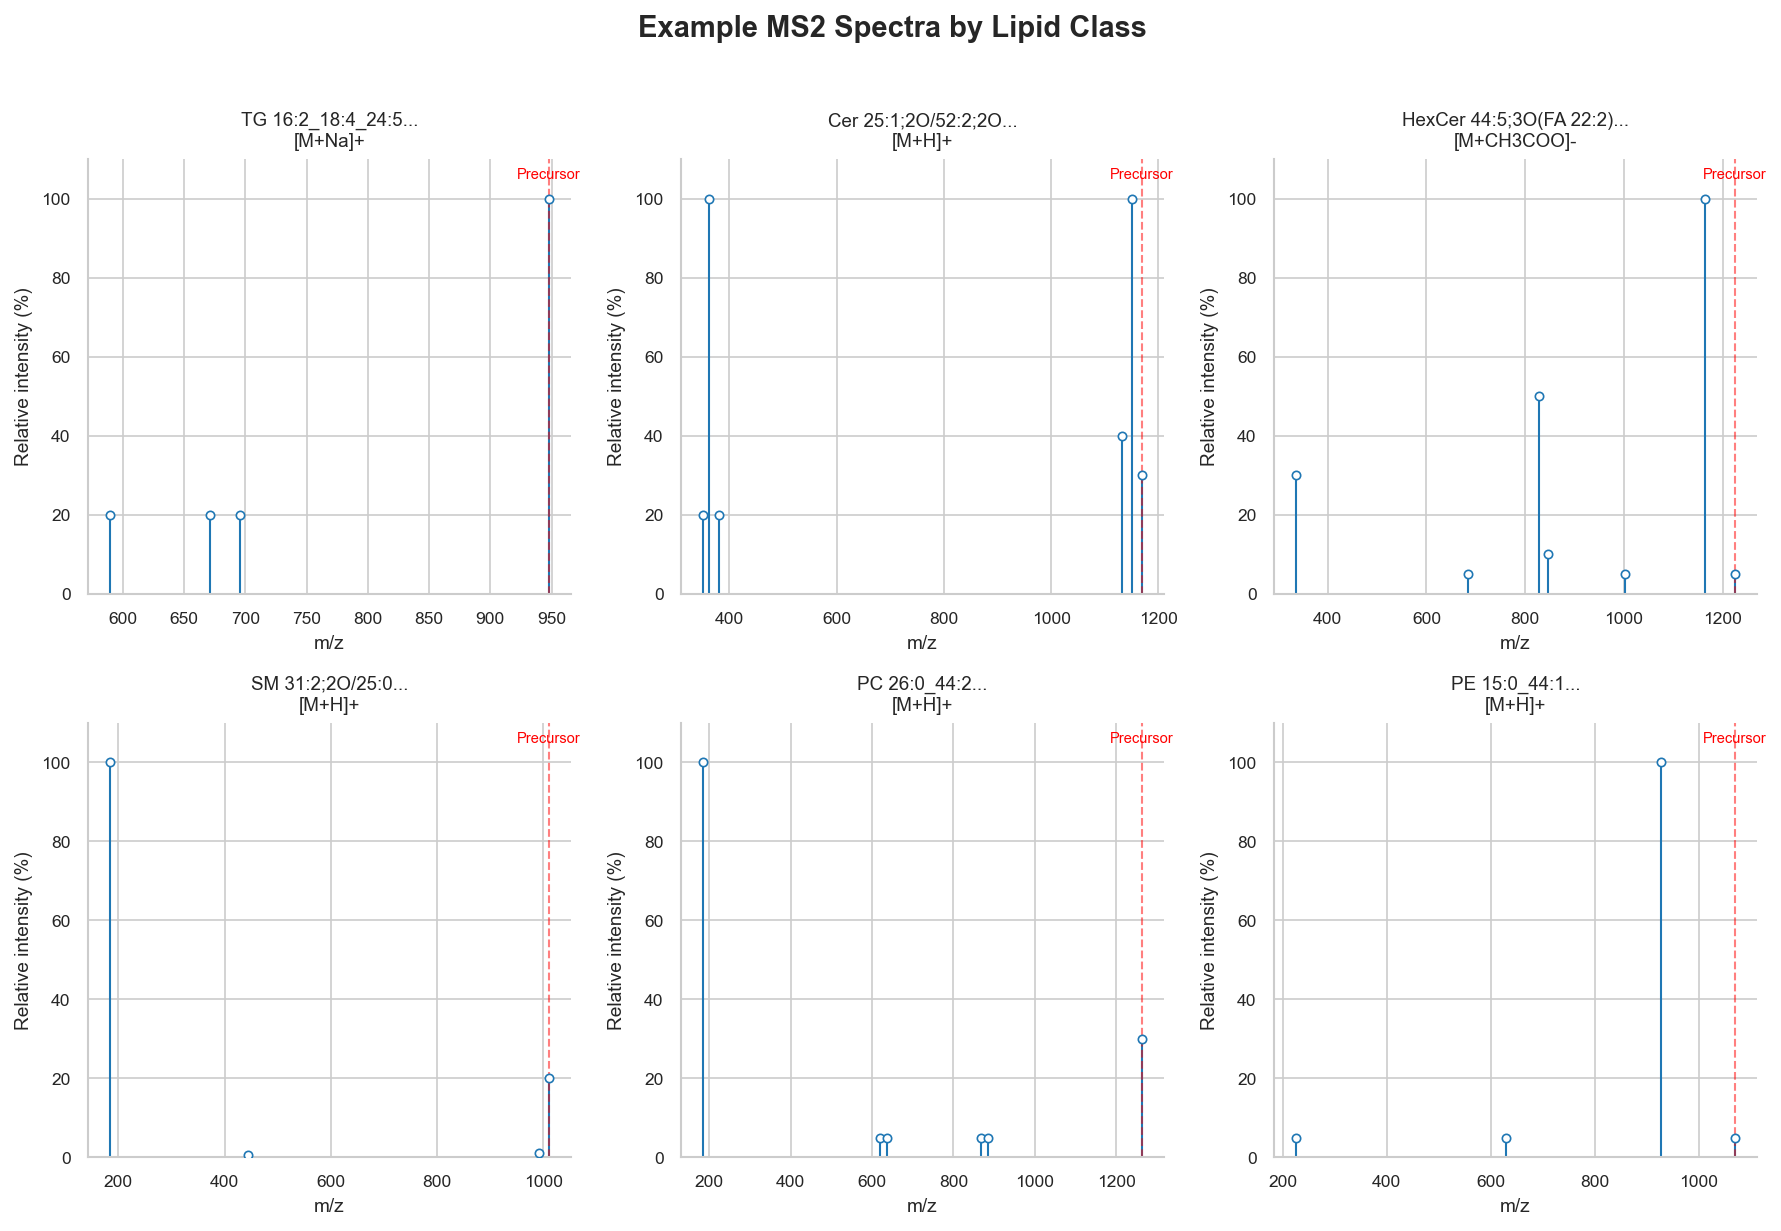

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes_flat = axes.flatten()

top_classes_ex = df["lipid_class"].value_counts().head(6).index

for ax, lipid_class in zip(axes_flat, top_classes_ex):
    subset = df[df["lipid_class"] == lipid_class]
    example = subset.sample(1, random_state=42).iloc[0]

    mzs = np.array(example["mz_list"])
    ints = np.array(example["intensity_list"])

    if max(ints) > 0:
        ints = ints / max(ints) * 100

    ax.vlines(mzs, 0, ints, colors="#1f77b4", linewidth=1)
    ax.scatter(mzs, ints, edgecolors="#1f77b4", facecolors="white", s=16, linewidths=0.8, zorder=3)

    ax.set_xlabel("m/z")
    ax.set_ylabel("Relative intensity (%)")
    ax.set_title(f"{example['name'][:30]}...\n{example['adduct_name']}", fontsize=9)
    ax.set_ylim(0, 110)

    ax.axvline(example["precursor_mz"], color="red", linestyle="--",
               alpha=0.5, linewidth=1)
    ax.text(example["precursor_mz"], 105, "Precursor", fontsize=7,
            ha="center", color="red")

plt.suptitle("Example MS2 Spectra by Lipid Class", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "example_spectra.png"), bbox_inches="tight")
plt.show()

## 17. Template Heatmap

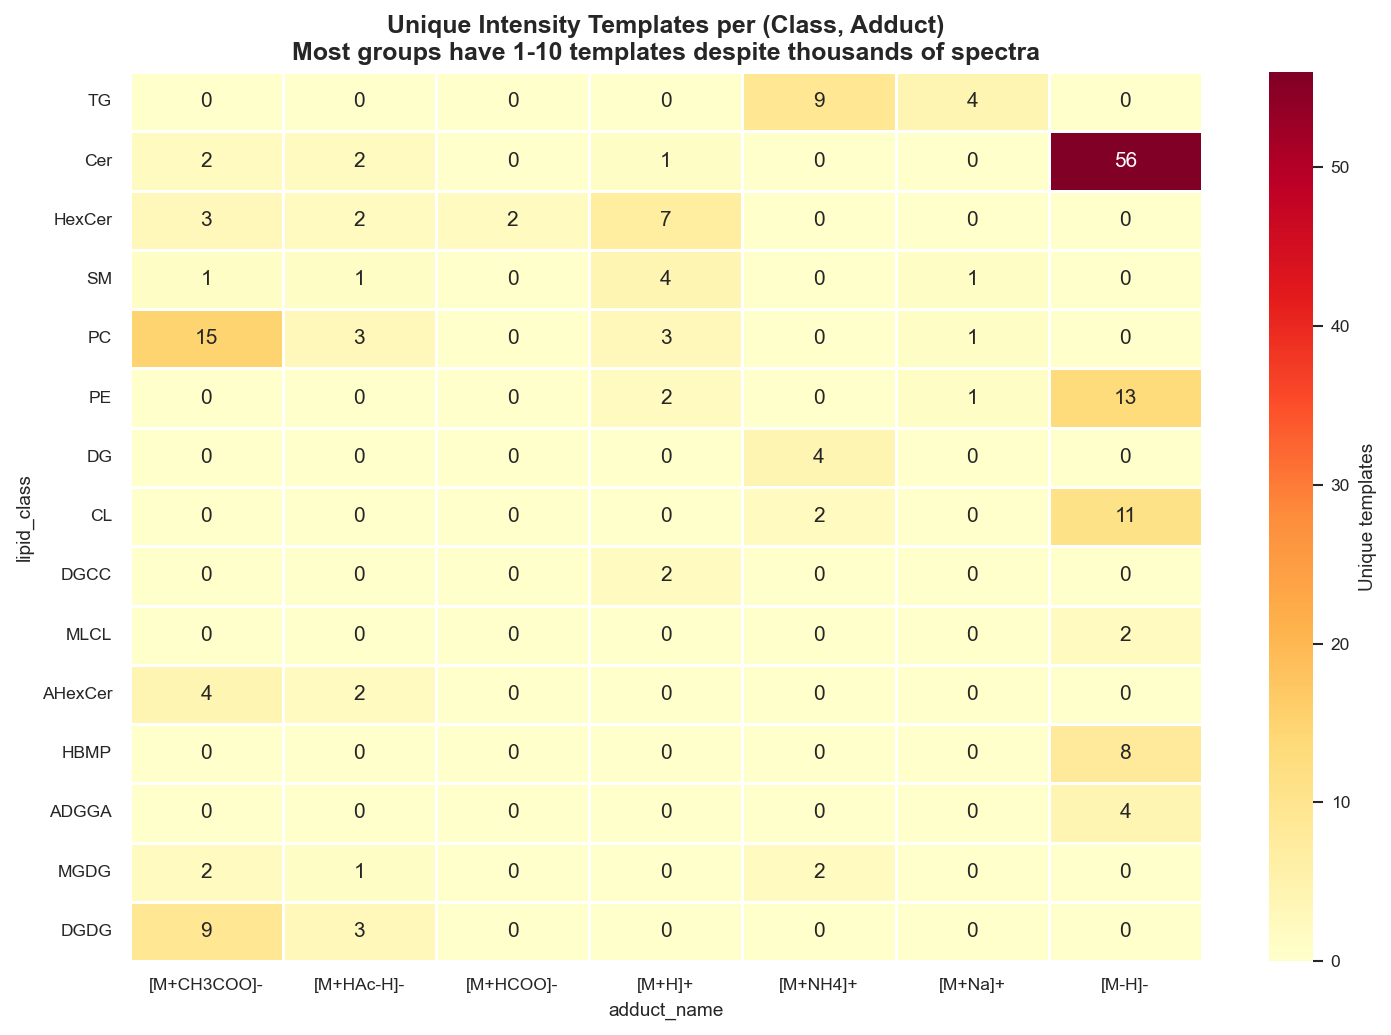

In [19]:
# Pivot: rows = top lipid classes, columns = adducts, values = unique templates
top_classes = df["lipid_class"].value_counts().head(15).index.tolist()
pivot = group_stats[group_stats["lipid_class"].isin(top_classes)].pivot_table(
    index="lipid_class", columns="adduct_name", values="n_templates", fill_value=0,
)
pivot = pivot.reindex(top_classes)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt="g", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "Unique templates"}, ax=ax)
ax.set_title(
    "Unique Intensity Templates per (Class, Adduct)\n"
    "Most groups have 1-10 templates despite thousands of spectra",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "template_heatmap.png"), bbox_inches="tight")
plt.show()

df.drop(columns=["_template_key"], inplace=True)

## 18. Train/Val/Test Split

Split       Spectra    Compounds    Classes     Frac
----------------------------------------------------
train       441,571      432,764         73    80.0%
val          55,139       54,096         62    10.0%
test         55,180       54,096         62    10.0%

Class distribution (top 10):
Class                train        val       test
------------------------------------------------
TG                  23.9%     23.9%     23.9%
Cer                 22.3%     22.3%     22.3%
HexCer               6.7%      6.7%      6.7%
SM                   4.8%      4.8%      4.8%
PC                   3.7%

      3.7%      3.7%
PE                   3.7%      3.7%      3.6%
DG                   3.5%      3.5%      3.5%
CL                   3.0%      3.0%      3.0%
DGCC                 2.5%      2.5%      2.5%
MLCL                 2.1%      2.1%      2.1%


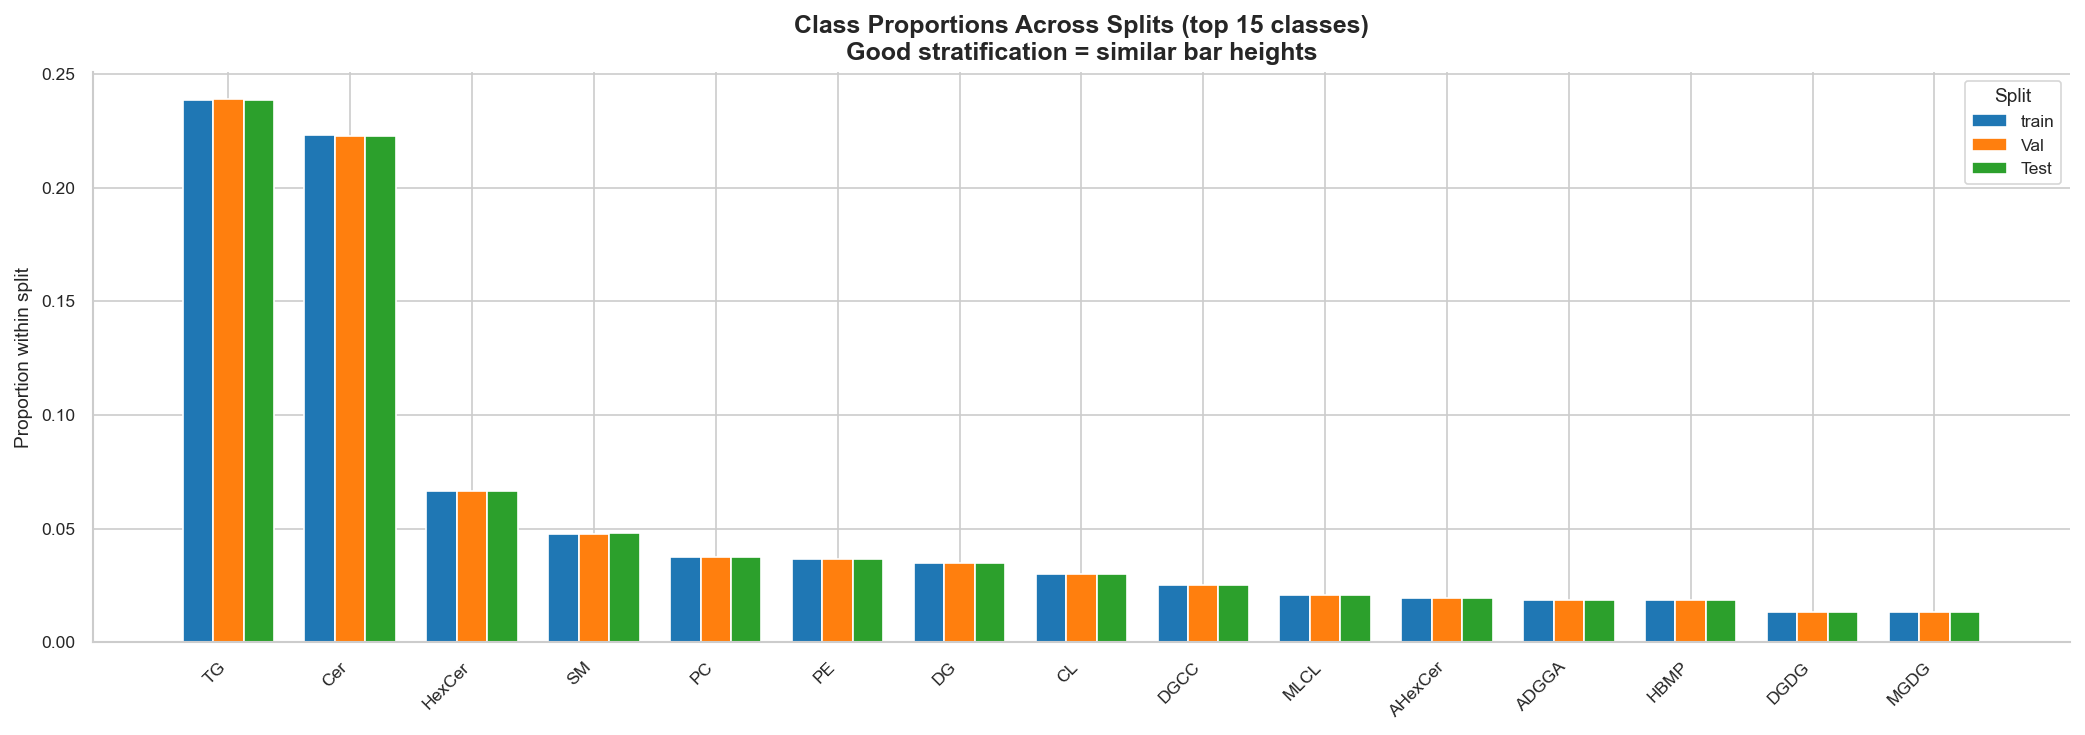

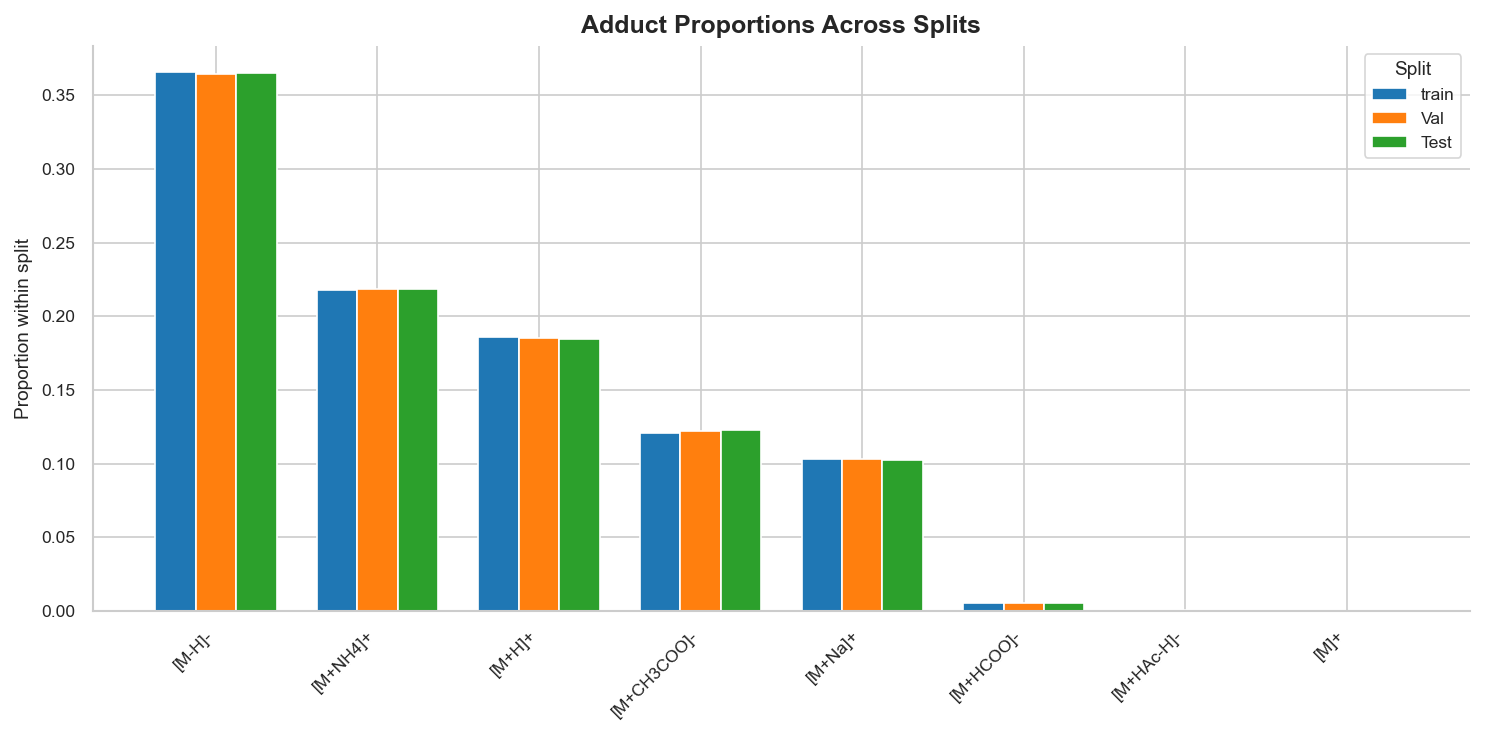

In [20]:
from src.data.split import split_dataset, print_split_stats

splits = split_dataset(df)
print_split_stats(splits)

# --- split_stratification.png ---
top15 = splits["train"]["lipid_class"].value_counts().head(15).index.tolist()
split_names = list(splits.keys())

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(top15))
w = 0.25
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for i, (name, color) in enumerate(zip(split_names, colors)):
    sdf = splits[name]
    props = [(sdf["lipid_class"] == c).mean() for c in top15]
    ax.bar(x + i * w, props, w, label=name.capitalize() if name != "train" else "train", color=color)

ax.set_xticks(x + w)
ax.set_xticklabels(top15, rotation=45, ha="right")
ax.set_ylabel("Proportion within split")
ax.set_title("Class Proportions Across Splits (top 15 classes)\nGood stratification = similar bar heights",
             fontsize=12, fontweight="bold")
ax.legend(title="Split")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "split_stratification.png"), bbox_inches="tight")
plt.show()

# --- split_adduct_coverage.png ---
all_adducts = df["adduct_name"].value_counts().index.tolist()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(all_adducts))

for i, (name, color) in enumerate(zip(split_names, colors)):
    sdf = splits[name]
    props = [(sdf["adduct_name"] == a).mean() for a in all_adducts]
    ax.bar(x + i * w, props, w, label=name.capitalize() if name != "train" else "train", color=color)

ax.set_xticks(x + w)
ax.set_xticklabels(all_adducts, rotation=45, ha="right")
ax.set_ylabel("Proportion within split")
ax.set_title("Adduct Proportions Across Splits", fontsize=12, fontweight="bold")
ax.legend(title="Split")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "split_adduct_coverage.png"), bbox_inches="tight")
plt.show()

## 19. Diagnostic Ion Prevalence

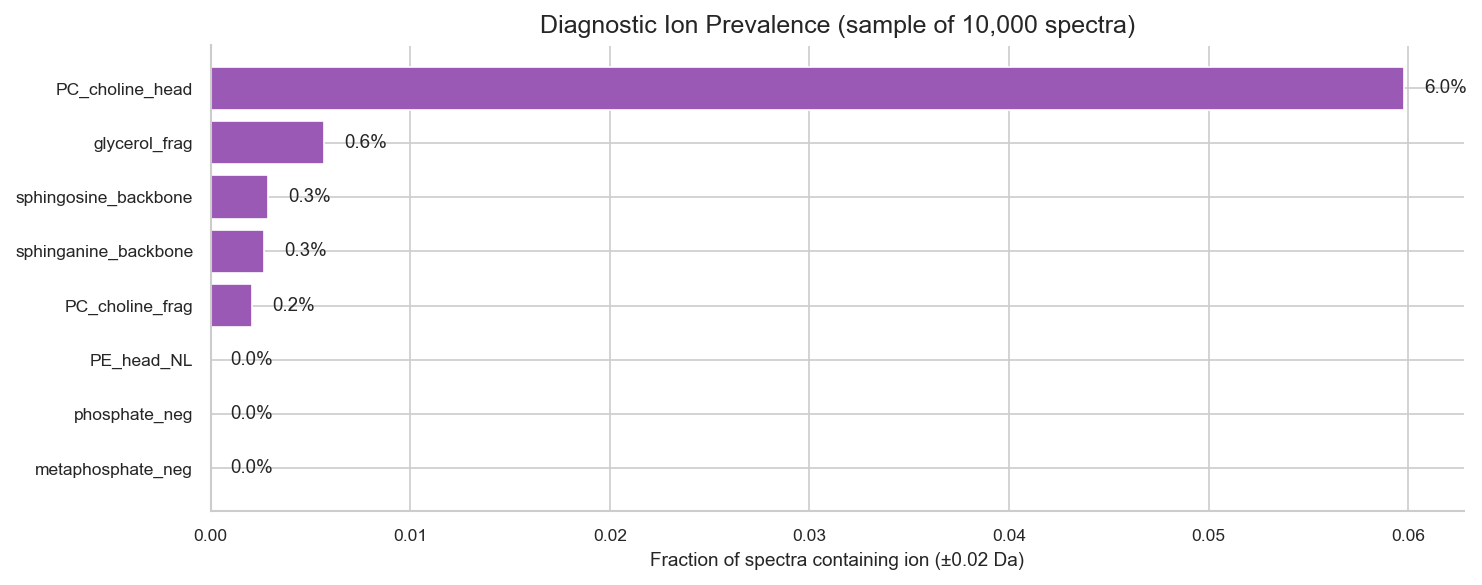

In [21]:
DIAGNOSTIC_IONS = {
    184.0733: "PC_choline_head",
    86.0964:  "PC_choline_frag",
    141.0191: "PE_head_NL",
    264.2686: "sphingosine_backbone",
    282.2792: "sphinganine_backbone",
    97.9769:  "phosphate_neg",
    79.9663:  "metaphosphate_neg",
    74.0368:  "glycerol_frag",
}

n_sample = 10_000
sample = df.sample(n_sample, random_state=42)
tol = 0.02

ion_counts = {}
for mz_target, label in DIAGNOSTIC_IONS.items():
    count = 0
    for mzs in sample["mz_list"]:
        if np.any(np.abs(np.asarray(mzs) - mz_target) <= tol):
            count += 1
    ion_counts[label] = count

ion_df = pd.Series(ion_counts).sort_values(ascending=False)
ion_frac = ion_df / n_sample

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(range(len(ion_df)), ion_frac.values, color="#9b59b6")
ax.set_yticks(range(len(ion_df)))
ax.set_yticklabels(ion_df.index)
ax.invert_yaxis()
ax.set_xlabel(f"Fraction of spectra containing ion (\u00b1{tol} Da)")
ax.set_title(f"Diagnostic Ion Prevalence (sample of {n_sample:,} spectra)")

for bar, frac in zip(bars, ion_frac.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{frac:.1%}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "diagnostic_ion_prevalence.png"), bbox_inches="tight")
plt.show()

## 20. Neutral Loss Prevalence

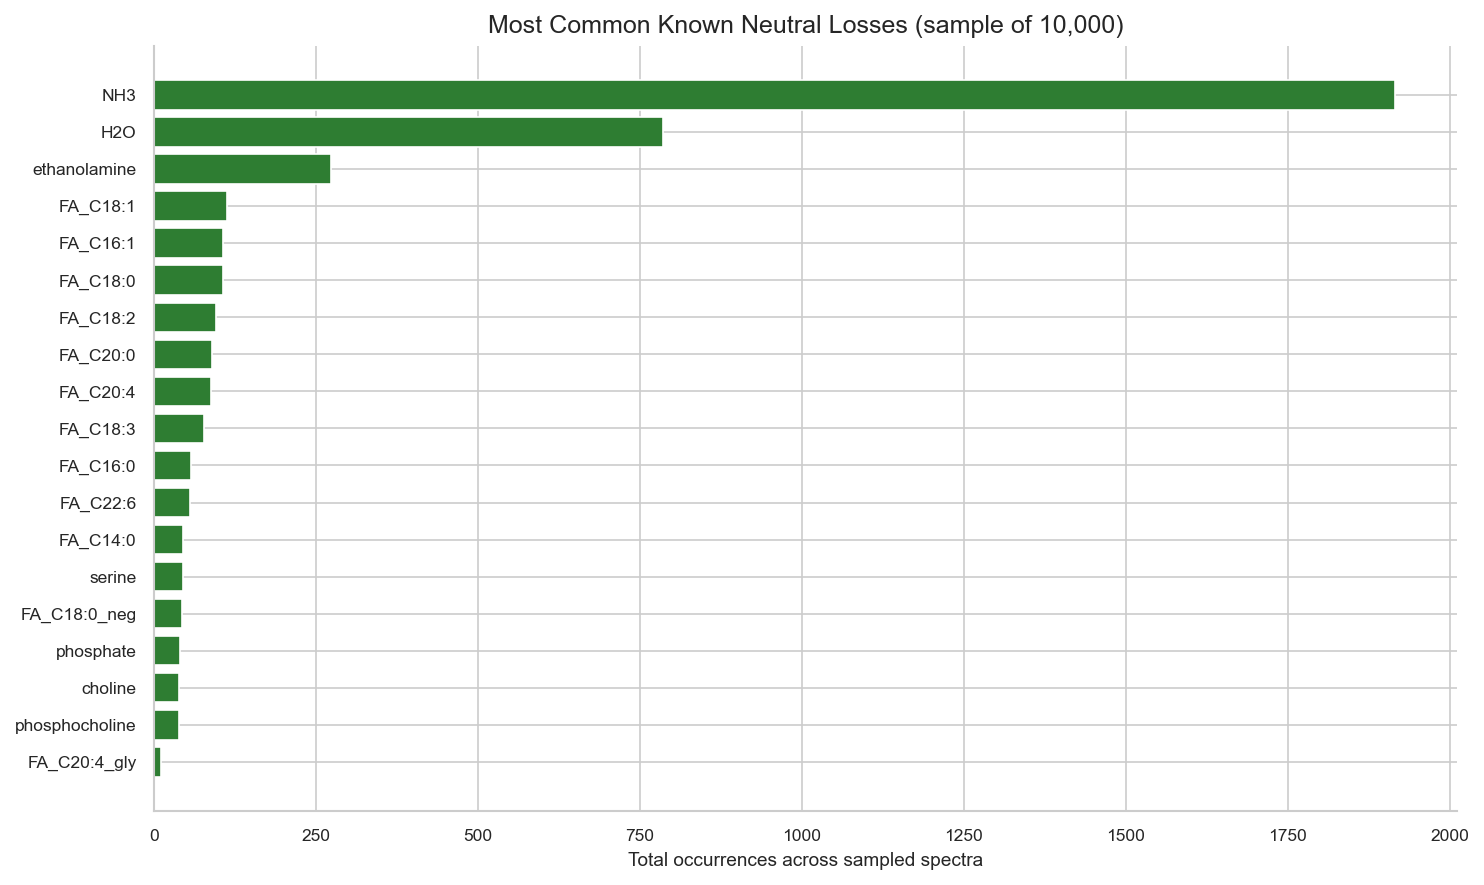

In [22]:
KNOWN_NEUTRAL_LOSSES = {
    'H2O': 18.0106, 'NH3': 17.0265, 'CO': 27.9949, 'CO2': 43.9898,
    'CH2': 14.0157, 'C2H4': 28.0313,
    'choline': 183.0660, 'ethanolamine': 141.0191,
    'serine': 185.0089, 'inositol': 260.0528,
    'phosphocholine': 183.0660, 'phosphate': 97.9769,
    'FA_C14:0': 228.2089, 'FA_C16:0': 256.2402, 'FA_C16:1': 254.2246,
    'FA_C18:0': 284.2715, 'FA_C18:1': 282.2559, 'FA_C18:2': 280.2402,
    'FA_C18:3': 278.2246, 'FA_C20:0': 312.3028, 'FA_C20:4': 304.2402,
    'FA_C22:6': 328.2402,
}

# Also check negative-mode fatty acid losses as [M-H-RCOOH]- and glycerol ester losses
EXTRA_LOSSES = {
    'FA_C20:4_gly': 304.2402 + 74.0368,
    'FA_C18:0_neg': 284.2715 - 1.0079,
}
all_losses = {**KNOWN_NEUTRAL_LOSSES, **EXTRA_LOSSES}

nl_counts = {name: 0 for name in all_losses}
for _, row in sample.iterrows():
    mzs = np.asarray(row["mz_list"])
    prec = row["precursor_mz"]
    losses = prec - mzs
    for name, mass in all_losses.items():
        if np.any(np.abs(losses - mass) <= tol):
            nl_counts[name] += 1

nl_series = pd.Series(nl_counts).sort_values(ascending=False)
nl_series = nl_series[nl_series > 0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(nl_series)), nl_series.values, color="#2e7d32")
ax.set_yticks(range(len(nl_series)))
ax.set_yticklabels(nl_series.index)
ax.invert_yaxis()
ax.set_xlabel("Total occurrences across sampled spectra")
ax.set_title(f"Most Common Known Neutral Losses (sample of {n_sample:,})")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "neutral_loss_prevalence.png"), bbox_inches="tight")
plt.show()